<a href="https://colab.research.google.com/github/nadisfeu/trabalhoClassPetsLLE/blob/main/TrabalhoClassPets_baseline_e_testes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

nandisfeu_the_oxford_iiit_pet_dataset_path = kagglehub.dataset_download('nandisfeu/the-oxford-iiit-pet-dataset')

print('Data source import complete.')


# *Bibliotecas e exploração do dataset*

In [ ]:
import numpy as np
import random
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# bibliotecas para treino, teste e validação, modelo de regressão e avaliação do modelo
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

# bibliotecas para avaliação de desempenho dos modelos de classificação
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from skimage.transform import resize
from skimage.io import imread

from xgboost import XGBClassifier

In [ ]:
dataset_path = '/kaggle/input/the-oxford-iiit-pet-dataset/'
dataset_path

'/kaggle/input/the-oxford-iiit-pet-dataset/'

In [ ]:
# --- CONFIGURAÇÃO ---
base_dir = dataset_path + 'images/images/' # Onde estão as fotos
annot_file = dataset_path + 'annotations/annotations/list.txt' #Onde estão as labels
trimap_dir = dataset_path +'annotations/annotations/trimaps' #Onde estão os trimaps
dim = 64

# 1. Carregar o mapa (DataFrame)
df = pd.read_csv(annot_file, sep=' ', comment='#', header=None,
                 names=['filename', 'class_id', 'species', 'breed_id'])

# Adicionar a extensão .jpg, pois o arquivo de texto não tem
df['filename'] = df['filename'] + '.jpg'
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7349 entries, 0 to 7348
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  7349 non-null   object
 1   class_id  7349 non-null   int64 
 2   species   7349 non-null   int64 
 3   breed_id  7349 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 229.8+ KB


In [ ]:
print("Total de imagens no DF:", len(df))
print("Raças únicas no DF:", df['breed_id'].unique())
print("Quantas raças tem:", len(df['breed_id'].unique()))
print("Quantas classes tem:", len(df['class_id'].unique()))
df.head()

Total de imagens no DF: 7349
Raças únicas no DF: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]
Quantas raças tem: 25
Quantas classes tem: 37


,filename,class_id,species,breed_id
0,Abyssinian_100.jpg,1,1,1
1,Abyssinian_101.jpg,1,1,1
2,Abyssinian_102.jpg,1,1,1
3,Abyssinian_103.jpg,1,1,1
4,Abyssinian_104.jpg,1,1,1


exemplo da imagem

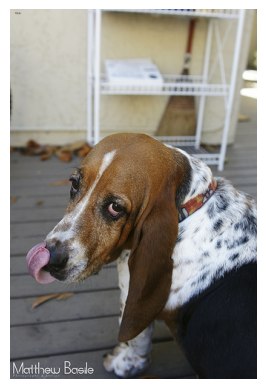

/kaggle/input/the-oxford-iiit-pet-dataset/images/images/basset_hound_72.jpg


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# pega uma imagem aleatoria do dataset para exemplo
caminho_img = base_dir + df['filename'][np.random.randint(0, df.shape[0])]

img = mpimg.imread(caminho_img)
plt.imshow(img)
plt.axis('off') # Opcional: remove os eixos com números
plt.show()

print(caminho_img)

# **funcoes**

In [ ]:
def visualizar_erro_matriz(classe_real, classe_predita,X_test, y_test, y_pred, qtd=5):
    """
    Pega aleatoriamente imagens de uma célula específica da Matriz de Confusão.

    Args:
        classe_real: O valor que a imagem REALMENTE é (ex: 0 ou 'Abyssinian')
        classe_predita: O valor que o modelo ERROU ao prever (ex: 1 ou 'Beagle')
    """

    # 1. Filtra exatamente a interseção da Matriz (Célula [Real, Predito])
    # Procura onde o y_test é igual ao Real E o y_pred é igual ao Predito
    indices_celula = np.where((y_test == classe_real) & (y_pred == classe_predita))[0]

    total_casos = len(indices_celula)
    print(f"Analisando confusão: Real '{classe_real}' -> Predito '{classe_predita}'")
    print(f"Total de imagens nessa célula: {total_casos}")

    if total_casos == 0:
        print("Nenhum caso encontrado nessa interseção! Escolha outra célula.")
        return

    # 2. Sorteio Aleatório (Random Choice)
    # Se tiver menos imagens do que a qtd pedida, pega todas.
    qtd_plot = min(qtd, total_casos)
    indices_aleatorios = np.random.choice(indices_celula, size=qtd_plot, replace=False)

    # 3. Plotagem
    fig, ax = plt.subplots(1, qtd_plot, figsize=(15, 4))

    # Ajuste para caso seja apenas 1 imagem (o matplotlib não retorna lista nesse caso)
    if qtd_plot == 1: ax = [ax]

    for i, idx in enumerate(indices_aleatorios):
        # Pega a imagem achatada
        img_flat = X_test[idx]

        # Reconstrói (Logica do seu código: reshape e normalização)
        img_show = img_flat.reshape(dim,dim, 3)
        if img_show.max() <= 1.5:
            img_show = (img_show * 255).astype(np.uint8)
        else:
            img_show = img_show.astype(np.uint8)

        # Exibe
        ax[i].imshow(img_show)
        ax[i].set_title(f"Index: {idx}\n(Confundiu com {classe_predita})", fontsize=10)
        ax[i].axis('off')

    plt.suptitle(f"Exemplos Reais: Era {classe_real}, Modelo disse {classe_predita}", fontsize=14)
    plt.show()



In [ ]:
def random_erasing_treino(img_flat, p=0.5, s_l=0.02, s_h=0.2, r_1=0.3):
    """
    Aplica Random Erasing em uma imagem achatada (1D).
    """
    # 1. Se cair na chance de não fazer nada, retorna a original
    if np.random.rand() > p:
        return img_flat

    img = img_flat.reshape(dim, dim, 3).copy()

    img_h, img_w, _ = img.shape
    area = img_h * img_w

    # Tenta criar o retângulo (limite de tentativas para não travar)
    for _ in range(100):
        target_area = np.random.uniform(s_l, s_h) * area
        aspect_ratio = np.random.uniform(r_1, 1 / r_1)

        h = int(round(np.sqrt(target_area * aspect_ratio)))
        w = int(round(np.sqrt(target_area / aspect_ratio)))

        if w < img_w and h < img_h:
            x1 = np.random.randint(0, img_h - h)
            y1 = np.random.randint(0, img_w - w)

            # Preenche com ruído colorido
            if img.dtype == np.uint8:
                img[x1:x1+h, y1:y1+w, :] = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
            else:
                img[x1:x1+h, y1:y1+w, :] = np.random.rand(h, w, 3)

            # 3. Importante: Achatar de volta para 1D antes de devolver
            return img.flatten()

    # Se falhar em gerar um retângulo válido, devolve sem alteração
    return img_flat

# **pré processamento de dados**

ler as imagens e redimensionar

In [ ]:
def data_species(dim,base_dir,df):
    data_x = []
    data_y = []
    for i in range(df.shape[0]):
      #print(f"processando imagem {i} / {df['filename'][i]}")
      try:
        #leio o caminho da imagem
        img_path = base_dir + df['filename'][i]
        #faço a abertura da imagem
        img = imread(img_path)
        #redimensionamento da imagem
        img_resized = resize(img, (dim, dim), anti_aliasing=True)

        img_flat = img_resized.flatten()

        if len(img_flat) == dim * dim * 3: # Garante que tem 3 canais de cor (RGB)
                data_x.append(img_flat)
                data_y.append(df['species'][i])
                #print(f"imagem {i} / {df['filename'][i]}")
      except:
        print(Fore.RED + f"Erro ao processar a imagem {img_path}")

    X = np.array(data_x)
    y = np.array(data_y)
    return X,y


In [ ]:
X,y = data_species(dim,base_dir,df)

print(X.shape)
print(y.shape)

print(X[1])

(7346, 12288)
(7346,)
[0.93138125 0.86554594 0.84298126 ... 1.         1.         1.        ]


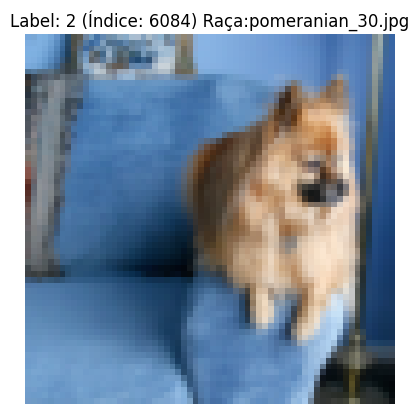

In [ ]:
# Vamos pegar uma imagem aleatória do seu banco de dados processado (X)
index = random.randint(0, len(X)-1)
imagem_achatada = X[index]
rotulo = y[index]

# REVERTER O PROCESSO:
imagem_reconstruida = imagem_achatada.reshape(dim, dim, 3)

plt.imshow(imagem_reconstruida)
plt.title(f"Label: {rotulo} (Índice: {index}) Raça:{df['filename'][index]}")
plt.axis('off')
plt.show()

In [ ]:
import cv2

def load_images(files):
  images = [] # list for the images
  labels = [] # list for labels

  for img in files:
    image = cv2.imread(img)

    if image is not None:
      image = cv2.resize(image, (64, 64))  # Resize images to a consistent size
      images.append(image.flatten())

      if any(ch.isupper() for ch in str(img)):
        labels.append(0)
      else:
        labels.append(1)

  return np.array(images), np.array(labels)

In [ ]:
filenames = []

for i in range(df['filename'].shape[0]):
    filenames.append(base_dir +df['filename'][i] )

X1,Y1 = load_images(filenames)

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


In [ ]:
print(X1.shape)
print(Y1.shape)

print(X1[1])

(7349, 12288)
(7349,)
[219 227 244 ... 255 255 255]


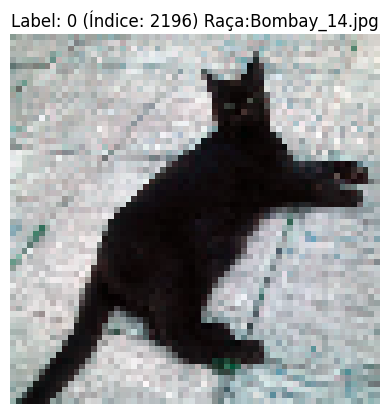

In [ ]:
# Vamos pegar uma imagem aleatória do seu banco de dados processado (X)
index = random.randint(0, len(X1)-1)
imagem_achatada = X1[index]
rotulo = Y1[index]

# REVERTER O PROCESSO:
imagem_reconstruida = imagem_achatada.reshape(dim, dim, 3)

plt.imshow(imagem_reconstruida)
plt.title(f"Label: {rotulo} (Índice: {index}) Raça:{df['filename'][index]}")
plt.axis('off')
plt.show()

del X1
del Y1

# **Divisão do Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                       test_size=0.2, # parâmetro da divisão 80/20
                                       random_state=42)

#deixando os rotulos em 0 e 1 para o treinamento
# gato = 0
# cachorro = 1
y_train = y_train - 1
y_test = y_test - 1

print("Valores únicos no y_test:", np.unique(y_test))
print("Matriz de features do dataset de treino:\tformato ", X_train.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test.shape)

Valores únicos no y_test: [0 1]
Matriz de features do dataset de treino:	formato  (5876, 12288)
Vetor de labels do dataset de treino:		formato  (5876,)
Matriz de features do dataset de teste:		formato  (1470, 12288)
Vetor de labels do dataset de teste:		formato  (1470,)


# **Teste binario**

random forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=None,
                            n_jobs=-1,
                            random_state=42,
                            class_weight='balanced' # balanceamento dos pesos para tentar driblar o desbalanceio das especies
                           )
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
# --- PREVISÃO ---
print("Fazendo previsões...")
y_pred = rf.predict(X_test)

# --- RESULTADOS ---
print(f"Acurácia: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test, y_pred, target_names=['Gato (0)', 'Cachorro (1)']))

Fazendo previsões...
Acurácia: 71.16%

Relatório Detalhado:
              precision    recall  f1-score   support

    Gato (0)       0.71      0.16      0.26       467
Cachorro (1)       0.71      0.97      0.82      1003

    accuracy                           0.71      1470
   macro avg       0.71      0.56      0.54      1470
weighted avg       0.71      0.71      0.64      1470



In [ ]:
y_probas_forest = cross_val_predict(rf, X_train, y_train,
                                    cv=3, method="predict_proba")

y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train, y_scores_forest)

roc_auc = roc_auc_score(y_train, y_scores_forest)
print("ROC AUC:%.4f"%roc_auc)

fpr_forest, tpr_forest, thresholds = roc_curve(y_train, y_scores_forest)

ROC AUC:0.6830


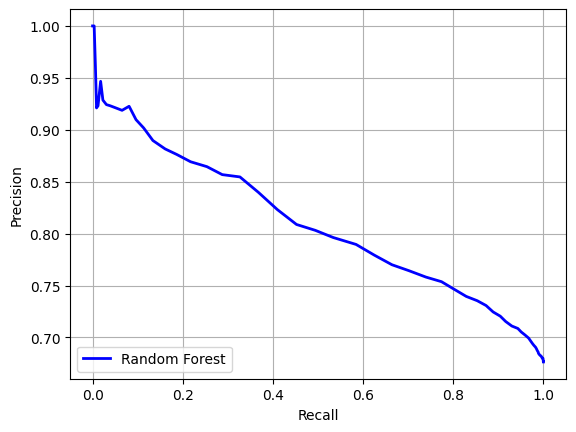

In [ ]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
#plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend(loc="lower left")
plt.draw()

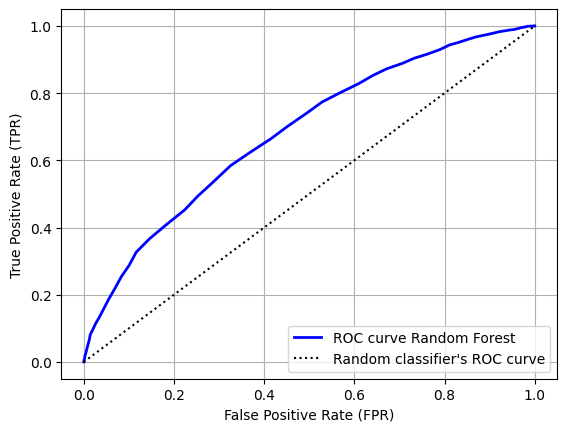

In [ ]:
#plt.plot(fpr, tpr, "--", linewidth=2, label="ROC curve SGD")
plt.plot(fpr_forest, tpr_forest, "b-", linewidth=2, label="ROC curve Random Forest")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(True)
plt.legend(loc="lower right")
plt.draw()

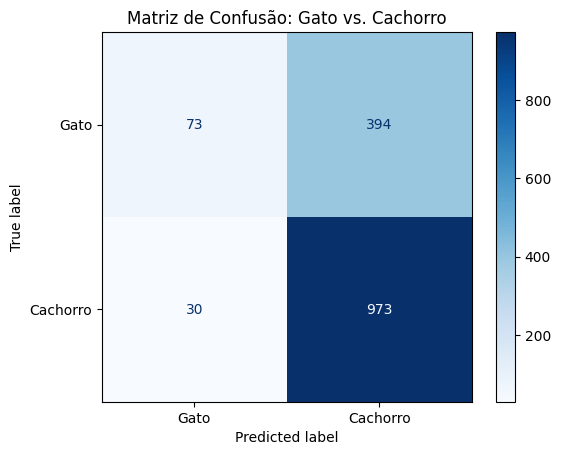

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Gato', 'Cachorro'],
    cmap='Blues'
)

plt.title("Matriz de Confusão: Gato vs. Cachorro")
plt.grid(False)
plt.show()

muito erro para classificar gatos, a classificação tende a cachorro, e a taxa de erro mt baixa pra cachorro  

# **Upsampling para o teste binario**


criando um novo dataset mas fazendo um aumento de dados para os gatos

In [ ]:
from skimage.transform import rotate

def data_species_up(dim,base_dir,df):
    data_x = []
    data_y = []
    for i in range(df.shape[0]):
      #print(f"processando imagem {i} / {df['filename'][i]}")
      try:
        #leio o caminho da imagem
        img_path = base_dir + df['filename'][i]
        #faço a abertura da imagem
        img = plt.imread(img_path)
        #redimensionamento da imagem
        img_resized = resize(img, (dim, dim), anti_aliasing=True)

        img_flat = img_resized.flatten()

        if len(img_flat) == dim * dim * 3: # Garante que tem 3 canais de cor (RGB)
                data_x.append(img_flat)
                data_y.append(df['species'][i])

                if df['species'][i] == 1:

                    # # Rotação 15 graus
                    # img_rot15 = rotate(img_resized, 15, mode='edge')
                    # data_x.append(img_rot15.flatten())
                    # data_y.append(1) # Força o label 1 (Gato)

                    # # Rotação -15 graus
                    # img_rot_neg15 = rotate(img_resized, -15, mode='edge')
                    # data_x.append(img_rot_neg15.flatten())
                    # data_y.append(1)

                    # Espelhamento
                    img_flip = np.fliplr(img_resized)
                    data_x.append(img_flip.flatten())
                    data_y.append(1)

      except:
        print(Fore.RED + f"Erro ao processar a imagem {img_path}")

    X = np.array(data_x)
    y = np.array(data_y)
    return X,y


In [ ]:
X_up,y_up = data_species_up(dim,base_dir,df)
print(X_up.shape)
print(y_up.shape)

print(X_up[1])

(9714, 12288)
(9714,)
[0.98799377 0.98759011 0.99425866 ... 0.04003567 0.04743331 0.10906921]


divisao do dataset

In [ ]:
X_train_up, X_test_up, y_train_up, y_test_up = train_test_split(X_up,y_up,
                                                               test_size=0.2, # parâmetro da divisão 80/20
                                                               random_state=42)

#deixando os rotulos em 0 e 1 para o treinamento
# gato = 0
# cachorro = 1
y_train_up = y_train_up - 1
y_test_up = y_test_up - 1

print("Valores únicos no y_test:", np.unique(y_test))
print("Matriz de features do dataset de treino:\tformato ", X_train_up.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train_up.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test_up.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test_up.shape)

Valores únicos no y_test: [0 1]
Matriz de features do dataset de treino:	formato  (7771, 12288)
Vetor de labels do dataset de treino:		formato  (7771,)
Matriz de features do dataset de teste:		formato  (1943, 12288)
Vetor de labels do dataset de teste:		formato  (1943,)


In [ ]:
classes, contagem = np.unique(y_train, return_counts=True)

# Mostra o resultado de forma limpa
print("Contagem de classes antes do upsampling:")
for classe, qtd in zip(classes, contagem):
    nome = "Gato" if classe == 0 else "Cachorro"
    print(f"Classe {classe} ({nome}): {qtd} imagens")


classes, contagem = np.unique(y_train_up, return_counts=True)

# Mostra o resultado de forma limpa
print("Contagem de classes:")
for classe, qtd in zip(classes, contagem):
    nome = "Gato" if classe == 0 else "Cachorro"
    print(f"Classe {classe} ({nome}): {qtd} imagens")

Contagem de classes antes do upsampling:
Classe 0 (Gato): 1901 imagens
Classe 1 (Cachorro): 3975 imagens
Contagem de classes:
Classe 0 (Gato): 3770 imagens
Classe 1 (Cachorro): 4001 imagens


random forest para pós upsampling

In [ ]:
rf_up = RandomForestClassifier(n_estimators=100,
                            max_depth=None,
                            n_jobs=-1,
                            random_state=42,
                            class_weight='balanced' # balanceamento dos pesos para tentar driblar o desbalanceio das especies
                           )
rf_up.fit(X_train_up, y_train_up)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# --- PREVISÃO ---
print("Fazendo previsões...")
y_pred_up = rf.predict(X_test_up)

# --- RESULTADOS ---
print(f"Acurácia: {accuracy_score(y_test_up, y_pred_up)*100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test_up, y_pred_up, target_names=['Gato (0)', 'Cachorro (1)']))



Fazendo previsões...
Acurácia: 74.88%

Relatório Detalhado:
              precision    recall  f1-score   support

    Gato (0)       0.99      0.50      0.66       966
Cachorro (1)       0.67      0.99      0.80       977

    accuracy                           0.75      1943
   macro avg       0.83      0.75      0.73      1943
weighted avg       0.83      0.75      0.73      1943



In [ ]:
y_probas_forest_up = cross_val_predict(rf, X_train_up, y_train_up,
                                    cv=3, method="predict_proba")

y_scores_forest_up = y_probas_forest_up[:, 1]
precisions_forest_up, recalls_forest_up, thresholds_forest_up = precision_recall_curve(y_train_up, y_scores_forest_up)


roc_auc_up = roc_auc_score(y_train_up, y_scores_forest_up)
print("ROC AUC:%.4f"%roc_auc)

fpr_forest_up, tpr_forest_up, thresholds_up = roc_curve(y_train_up, y_scores_forest_up)

ROC AUC:0.6830


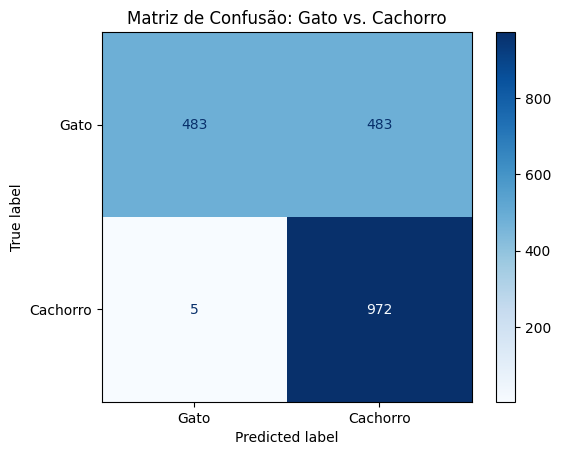

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_up,
    y_pred_up,
    display_labels=['Gato', 'Cachorro'],
    cmap='Blues'
)

plt.title("Matriz de Confusão: Gato vs. Cachorro")
plt.grid(False)
plt.show()

# **Teste visual comparativo**

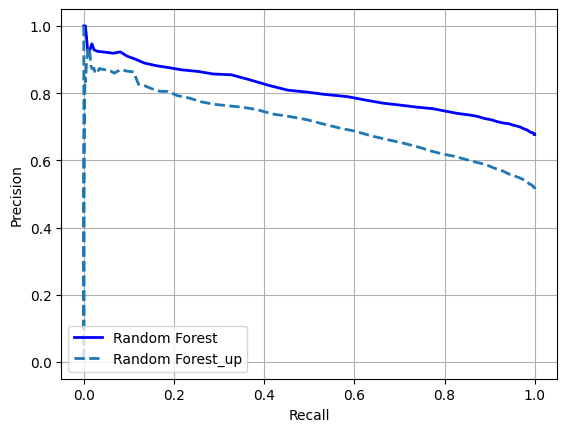

In [ ]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls_forest_up, precisions_forest_up, "--", linewidth=2, label="Random Forest_up")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend(loc="lower left")
plt.draw()

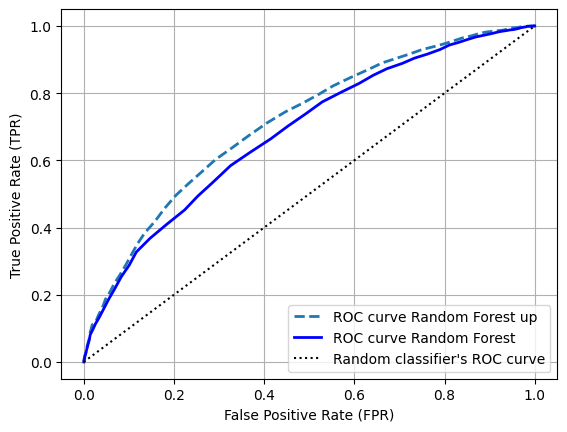

In [ ]:
plt.plot(fpr_forest_up, tpr_forest_up, "--", linewidth=2, label="ROC curve Random Forest up")
plt.plot(fpr_forest, tpr_forest, "b-", linewidth=2, label="ROC curve Random Forest")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(True)
plt.legend(loc="lower right")
plt.draw()

# **Usando o trimap para melhorar a predição**

# trimap com concatenação

In [ ]:



def data_species_trimap_concat(dim, base_dir, trimap_dir, df):
    data_x = []
    data_y = []

    for index, row in df.iterrows():
        try:
            # --- 1. Processar Imagem (Para todos) ---
            img_path = os.path.join(base_dir, row['filename'])
            img = imread(img_path) # Melhor usar skimage.io.imread

            img_resized = resize(img, (dim, dim), anti_aliasing=True, mode='reflect')
            img_flat = img_resized.flatten()

            # Verificação de canais (RGB)
            if len(img_flat) == dim * dim * 3:

                filename_png = row['filename'].replace('.jpg', '.png')
                trimap_path = os.path.join(trimap_dir, filename_png)
                # Inicializa vetor do trimap zerado (caso não ache o arquivo)
                trimap_vector = np.zeros(dim * dim)

                # Tenta carregar o trimap real
                if os.path.exists(trimap_path):
                    trimap = imread(trimap_path, as_gray = True)
                    # Resize sem anti_aliasing (order=0) para manter valores inteiros
                    trimap_resized = resize(trimap, (dim, dim), order=0, preserve_range=True, mode='reflect')
                    trimap_vector = trimap_resized.flatten()

                combined_features = np.concatenate([img_flat, trimap_vector])

                data_x.append(combined_features)
                data_y.append(row['species'])

        except Exception as e:
            print(f"Erro ao processar {row['filename']}: {e}")

    return np.array(data_x), np.array(data_y)

def data_species_concatenation(dim, base_dir, trimap_dir, df):
    data_x = []
    data_y = []

    print("Iniciando processamento com Concatenação (Img + Trimap)...")

    # Cálculos de tamanho esperado
    tamanho_img = dim * dim * 3
    tamanho_trimap = dim * dim
    tamanho_total = tamanho_img + tamanho_trimap

    for index, row in df.iterrows():
        try:
            # 1. Caminhos
            img_path = os.path.join(base_dir, row['filename'])
            filename_png = row['filename'].replace('.jpg', '.png')
            trimap_path = os.path.join(trimap_dir, filename_png)

            # Só processa se ambos existirem
            if os.path.exists(img_path) and os.path.exists(trimap_path):

                # 2. Leitura
                img = imread(img_path)
                trimap = imread(trimap_path, as_gray=True)

                # 3. Resize
                # Imagem (RGB)
                img_resized = resize(img, (dim, dim), anti_aliasing=True, mode='reflect')

                # Trimap (Cinza/Inteiros) - order=0 vital para não borrar
                trimap_resized = resize(trimap, (dim, dim), order=0, preserve_range=True, mode='reflect')

                # 4. Achatamento (Flatten)
                img_flat = img_resized.flatten()
                trimap_flat = trimap_resized.flatten()

                # --- VERIFICAÇÃO DE SEGURANÇA ---
                # Se a imagem for P&B original, ela terá tamanho errado. Vamos filtrar.
                if len(img_flat) == tamanho_img and len(trimap_flat) == tamanho_trimap:

                    # 5. CONCATENAÇÃO (O Pulo do Gato)
                    # np.concatenate cola um vetor no final do outro
                    features_combinadas = np.concatenate([img_flat, trimap_flat])

                    data_x.append(features_combinadas)
                    data_y.append(row['species'])
                else:
                    # Opcional: printar erro de dimensão
                    print(f"Erro de dimensão em {row['filename']}")
                    pass

        except Exception as e:
            print(f"Erro no arquivo {row['filename']}: {e}")

    # Retorna como arrays numpy
    return np.array(data_x), np.array(data_y)

In [ ]:
X_tri_concat,y_tri_concat = data_species_trimap_concat(dim,base_dir,trimap_dir,df)
# X_tri_concat,y_tri_concat = data_species_concatenation(dim, base_dir, trimap_dir, df)
print(X_tri_concat.shape)
print(y_tri_concat.shape)
print(X_tri_concat[1])

(7346, 16384)
(7346,)
[0.93138125 0.86554594 0.84298126 ... 2.         2.         2.        ]


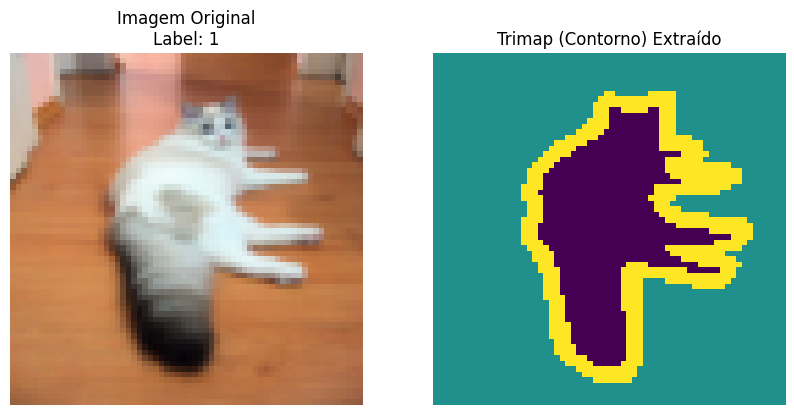

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

# --- CONFIGURAÇÃO ---
dim = 64
tamanho_rgb = dim * dim * 3

# 1. Pegar um exemplo aleatório
index = random.randint(0, len(X_tri_concat)-1)
vetor_combinado = X_tri_concat[index]
rotulo = y_tri_concat[index]

# --- O SEGREDINHO: SEPARAR AS PARTES ---
parte_imagem = vetor_combinado[:tamanho_rgb]
parte_trimap = vetor_combinado[tamanho_rgb:]

# 2. Reconstruir a Imagem RGB (CORREÇÃO AQUI)
# Precisamos multiplicar por 255 antes de converter para inteiro
img_reconstruida = (parte_imagem.reshape(dim, dim, 3) * 255).astype(np.uint8)

# 3. Reconstruir o Trimap
trimap_reconstruido = parte_trimap.reshape(dim, dim)

# --- VISUALIZAÇÃO LADO A LADO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot da Imagem
ax1.imshow(img_reconstruida)
ax1.set_title(f"Imagem Original\nLabel: {rotulo}")
ax1.axis('off')

# Plot do Trimap
# Dica: 'nearest' evita que o gráfico borre as bordas dos pixels
ax2.imshow(trimap_reconstruido, cmap='viridis', interpolation='nearest')
ax2.set_title("Trimap (Contorno) Extraído")
ax2.axis('off')

plt.show()

divisao do dataset

In [ ]:
X_train_concat, X_test_concat, y_train_concat, y_test_concat = train_test_split(X_tri_concat,y_tri_concat,
                                       test_size=0.2, # parâmetro da divisão 80/20
                                       random_state=42)

#deixando os rotulos em 0 e 1 para o treinamento
# gato = 0
# cachorro = 1
y_train_concat = y_train_concat - 1
y_test_concat = y_test_concat - 1

print("Valores únicos no y_test:", np.unique(y_test_concat))
print("Matriz de features do dataset de treino:\tformato ", X_train_concat.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train_concat.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test_concat.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test_concat.shape)

Valores únicos no y_test: [0 1]
Matriz de features do dataset de treino:	formato  (5876, 16384)
Vetor de labels do dataset de treino:		formato  (5876,)
Matriz de features do dataset de teste:		formato  (1470, 16384)
Vetor de labels do dataset de teste:		formato  (1470,)


In [ ]:
rf_concat = RandomForestClassifier(n_estimators=100,
                            max_depth=None,
                            n_jobs=-1,
                            random_state=42,
                            class_weight='balanced' # balanceamento dos pesos para tentar driblar o desbalanceio das especies
                           )
rf_concat.fit(X_train_concat, y_train_concat)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# --- PREVISÃO ---
print("Fazendo previsões...")
y_pred_concat = rf_concat.predict(X_test_concat)

# --- RESULTADOS ---
print(f"Acurácia: {accuracy_score(y_test_concat, y_pred_concat)*100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test_concat, y_pred_concat, target_names=['Gato (0)', 'Cachorro (1)']))



Fazendo previsões...
Acurácia: 72.93%

Relatório Detalhado:
              precision    recall  f1-score   support

    Gato (0)       0.75      0.22      0.34       467
Cachorro (1)       0.73      0.97      0.83      1003

    accuracy                           0.73      1470
   macro avg       0.74      0.59      0.59      1470
weighted avg       0.73      0.73      0.68      1470



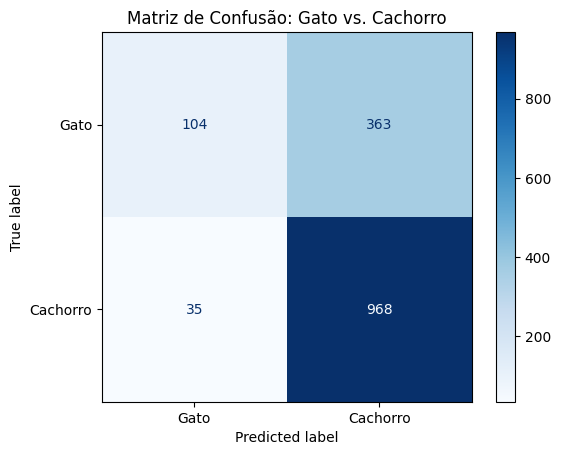

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_concat,
    y_pred_concat,
    display_labels=['Gato', 'Cachorro'],
    cmap='Blues'
)

plt.title("Matriz de Confusão: Gato vs. Cachorro")
plt.grid(False)
plt.show()

In [ ]:
y_probas_forest_concat = cross_val_predict(rf_concat, X_train_concat, y_train_concat,
                                    cv=3, method="predict_proba")

y_scores_forest_concat = y_probas_forest_concat[:, 1]
precisions_forest_concat, recalls_forest_concat, thresholds_forest_concat = precision_recall_curve(y_train_concat, y_scores_forest_concat)

roc_auc_concat = roc_auc_score(y_train_concat, y_scores_forest_concat)
print("ROC AUC:%.4f"%roc_auc_concat)

fpr_forest_concat, tpr_forest_concat, thresholds_concat = roc_curve(y_train_concat, y_scores_forest_concat)

ROC AUC:0.7462


# trimap com mascaramento

In [ ]:
def data_species_masking(dim, base_dir, trimap_dir, df):
    data_x = []
    data_y = []

    print("Iniciando processamento com Mascaramento (Recorte)...")

    for index, row in df.iterrows():
        try:

            img_path = os.path.join(base_dir, row['filename'])
            filename_png = row['filename'].replace('.jpg', '.png')
            trimap_path = os.path.join(trimap_dir, filename_png)

            img = imread(img_path)
            trimap = imread(trimap_path, as_gray=True)


            img_resized = resize(img, (dim, dim), anti_aliasing=True, mode='reflect')
            trimap_resized = resize(trimap, (dim, dim), order=0, preserve_range=True, mode='reflect')


            mascara = np.where(trimap_resized == 1, 1, 0) # 1 onde é animal, 0 onde é fundo

            # 4. Expandir máscara para 3 canais (RGB)
            mascara_rgb = np.stack((mascara, mascara, mascara), axis=2)

            # 5. MÁGICA: Multiplicação (Recorte)
            # Onde a máscara é 0, a imagem vira preto.
            img_recortada = img_resized * mascara_rgb

            # 6. Achatar e Salvar
            img_flat = img_recortada.flatten()

            if len(img_flat) == dim * dim * 3:
                data_x.append(img_flat)
                data_y.append(row['species'])

        except Exception as e:
            print(f"Erro ao processar {row['filename']}: {e}")

    return np.array(data_x), np.array(data_y)




In [ ]:
X_tri_mask,y_tri_mask = data_species_masking(dim,base_dir,trimap_dir,df)
print(X_tri_mask.shape)
print(y_tri_mask.shape)
print(X_tri_mask[1])

Iniciando processamento com Mascaramento (Recorte)...
Erro ao processar Egyptian_Mau_14.jpg: operands could not be broadcast together with shapes (64,64,4) (64,64,3) 
Erro ao processar Egyptian_Mau_186.jpg: operands could not be broadcast together with shapes (64,64,4) (64,64,3) 
Erro ao processar Abyssinian_5.jpg: operands could not be broadcast together with shapes (64,64,4) (64,64,3) 
(7346, 12288)
(7346,)
[0. 0. 0. ... 0. 0. 0.]


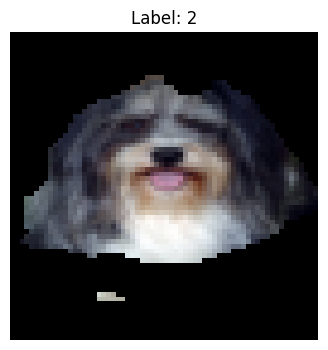

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 1. Pegue uma imagem processada aleatória
index = random.randint(0, len(X_tri_mask) - 1)
imagem_vetor = X_tri_mask[index]
label = y_tri_mask[index]


img_reconstruida = imagem_vetor.reshape(dim, dim, 3)

if img_reconstruida.max() <= 1.5:
    img_reconstruida = img_reconstruida * 255

# 5. Converte para Inteiro (pra o gráfico não ficar estranho)
img_final = np.clip(img_reconstruida, 0, 255).astype(np.uint8)

# 6. Plotar
plt.figure(figsize=(4,4))
plt.imshow(img_final)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

divisao do dataset

In [ ]:
X_train_mask, X_test_mask, y_train_mask, y_test_mask = train_test_split(X_tri_mask,y_tri_mask,
                                       test_size=0.2, # parâmetro da divisão 80/20
                                       random_state=42)

#deixando os rotulos em 0 e 1 para o treinamento
# gato = 0
# cachorro = 1
y_train_mask = y_train_mask - 1
y_test_mask = y_test_mask - 1

print("Valores únicos no y_test:", np.unique(y_test_mask))
print("Matriz de features do dataset de treino:\tformato ", X_train_mask.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train_mask.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test_mask.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test_mask.shape)

Valores únicos no y_test: [0 1]
Matriz de features do dataset de treino:	formato  (5876, 12288)
Vetor de labels do dataset de treino:		formato  (5876,)
Matriz de features do dataset de teste:		formato  (1470, 12288)
Vetor de labels do dataset de teste:		formato  (1470,)


random forest


In [ ]:
rf_mask = RandomForestClassifier(n_estimators=100,
                            max_depth=None,
                            n_jobs=-1,
                            random_state=42,
                            class_weight='balanced' # balanceamento dos pesos para tentar driblar o desbalanceio das especies
                           )
rf_mask.fit(X_train_mask, y_train_mask)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# --- PREVISÃO ---
print("Fazendo previsões...")
y_pred_mask = rf_mask.predict(X_test_mask)

# --- RESULTADOS ---
print(f"Acurácia: {accuracy_score(y_test_mask, y_pred_mask)*100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test_mask, y_pred_mask, target_names=['Gato (0)', 'Cachorro (1)']))



Fazendo previsões...
Acurácia: 74.29%

Relatório Detalhado:
              precision    recall  f1-score   support

    Gato (0)       0.71      0.32      0.44       467
Cachorro (1)       0.75      0.94      0.83      1003

    accuracy                           0.74      1470
   macro avg       0.73      0.63      0.64      1470
weighted avg       0.74      0.74      0.71      1470



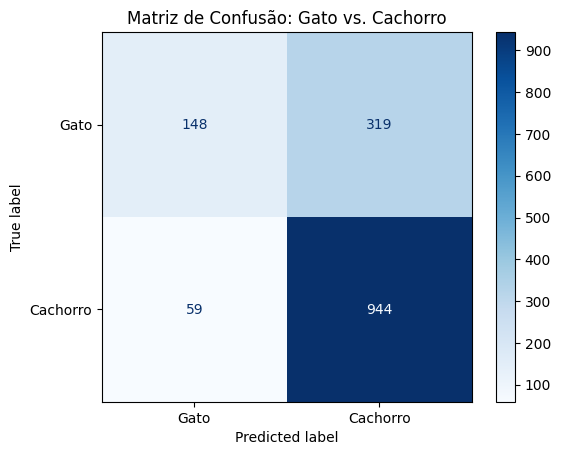

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_mask,
    y_pred_mask,
    display_labels=['Gato', 'Cachorro'],
    cmap='Blues'
)

plt.title("Matriz de Confusão: Gato vs. Cachorro")
plt.grid(False)
plt.show()

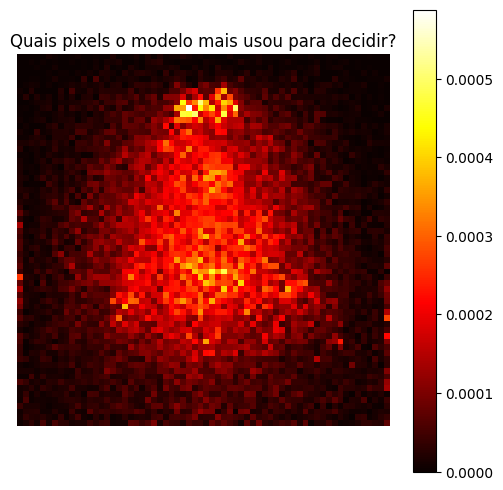

In [ ]:
importances = rf_mask.feature_importances_

# Redimensiona de volta para o formato da imagem (64x64x3)
# Tira a média dos 3 canais de cor para ficar uma imagem de calor 2D
heatmap = importances.reshape(dim, dim, 3).mean(axis=2)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap='hot')
plt.title("Quais pixels o modelo mais usou para decidir?")
plt.colorbar()
plt.axis('off')
plt.show()

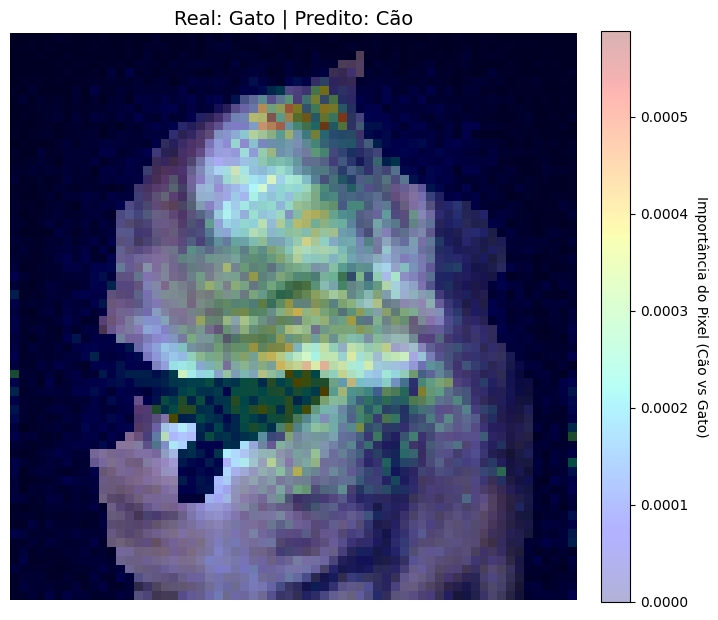

In [ ]:
importances = rf_mask.feature_importances_
heatmap = importances.reshape(dim, dim, 3).mean(axis=2)
nomes_binarios = {0: "Gato", 1: "Cão"}

indices_erros = np.where(y_test_mask != y_pred_mask)[0]
# --- PASSO 3: Escolher um Acerto Aleatório ---
indice_sorteado = np.random.choice(indices_erros)

# --- PASSO 4: Recuperar e Reconstruir a Imagem ---
img_flat = X_test_mask[indice_sorteado]
label_real = y_test_mask[indice_sorteado]
label_pred = y_pred_mask[indice_sorteado]

# Reshape e Conversão para visualização
img_rgb = img_flat.reshape(dim, dim, 3)

# Lógica de desnormalização (se estiver normalizado)
if img_rgb.max() <= 1.5:
    img_final = (img_rgb * 255).astype(np.uint8)
else:
    img_final = img_rgb.astype(np.uint8)

# --- PASSO 5: Plotar com Sobreposição ---
fig, ax = plt.subplots(figsize=(8, 8))

# 1. A Imagem Real
ax.imshow(img_final)

# 2. O Mapa de Calor (Transparente)
# alpha=0.3 deixa o fundo bem visível
sobreposicao = ax.imshow(heatmap, cmap='jet', alpha=0.3)

# Títulos
nome_r = nomes_binarios[label_real]
nome_p = nomes_binarios[label_pred]

ax.set_title(f"Real: {nome_r} | Predito: {nome_p}", fontsize=14)
ax.axis('off')

# Barra de cores
cbar = plt.colorbar(sobreposicao, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Importância do Pixel (Cão vs Gato)', rotation=270, labelpad=15)

plt.show()

In [ ]:
y_probas_forest_mask = cross_val_predict(rf_mask, X_train_mask, y_train_mask,
                                    cv=3, method="predict_proba")

y_scores_forest_mask = y_probas_forest_mask[:, 1]
precisions_forest_mask, recalls_forest_mask, thresholds_forest_mask = precision_recall_curve(y_train_mask, y_scores_forest_mask)

roc_auc_mask = roc_auc_score(y_train_mask, y_scores_forest_mask)
print("ROC AUC:%.4f"%roc_auc_mask)

fpr_forest_mask, tpr_forest_mask, thresholds_mask = roc_curve(y_train_mask, y_scores_forest_mask)

ROC AUC:0.7420


# **comparação visual com trimaps e sem**

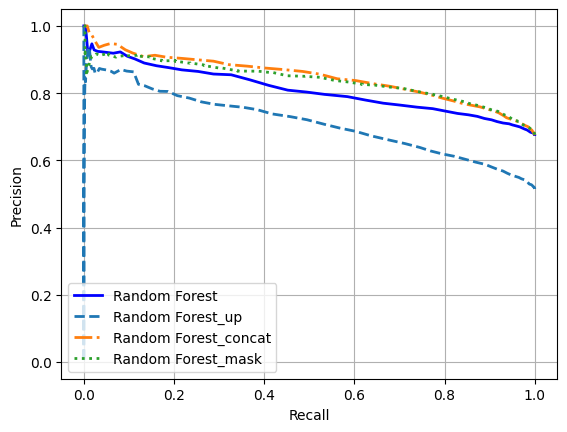

In [ ]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls_forest_up, precisions_forest_up, "--", linewidth=2, label="Random Forest_up")
plt.plot(recalls_forest_concat, precisions_forest_concat, "-.", linewidth=2, label="Random Forest_concat")
plt.plot(recalls_forest_mask, precisions_forest_mask, ":", linewidth=2, label="Random Forest_mask")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend(loc="lower left")
plt.draw()

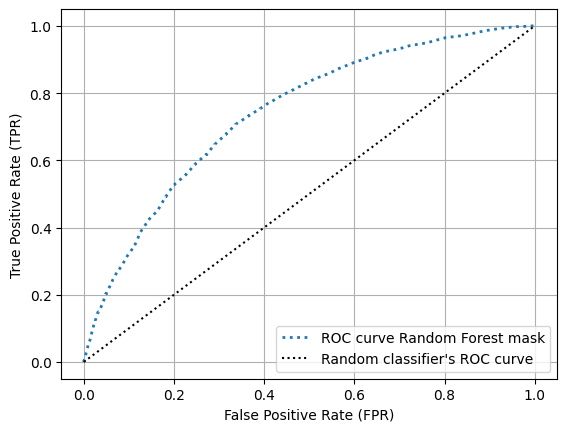

In [ ]:
# plt.plot(fpr_forest_up, tpr_forest_up, "--", linewidth=2, label="ROC curve Random Forest up")
# plt.plot(fpr_forest, tpr_forest, "b-", linewidth=2, label="ROC curve Random Forest")
# plt.plot(fpr_forest_concat, tpr_forest_concat, ".-", linewidth=2, label="ROC curve Random Forest concat")
plt.plot(fpr_forest_mask, tpr_forest_mask, ":", linewidth=2, label="ROC curve Random Forest mask")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(True)
plt.legend(loc="lower right")
plt.draw()

analise de falsos positivos

Total de erros encontrados: 378


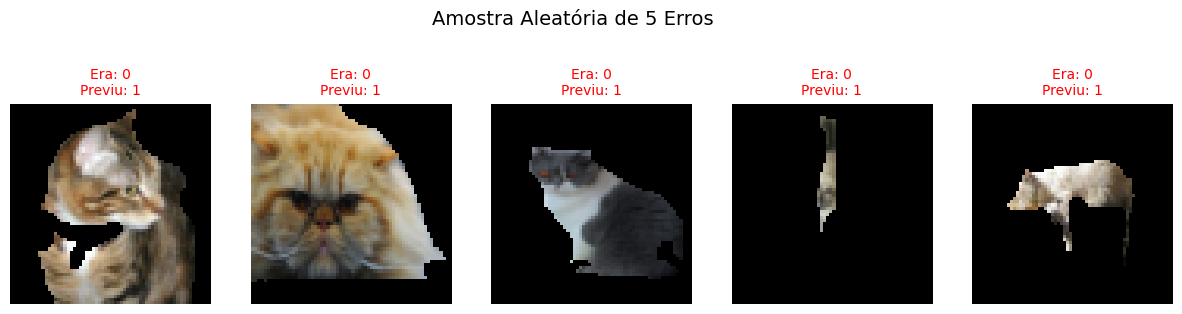

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Identificar ONDE estão os erros ---
# Cria uma lista com os índices onde o Real é diferente do Predito
indices_erros = np.where(y_test_mask != y_pred_mask)[0]

total_erros = len(indices_erros)
print(f"Total de erros encontrados: {total_erros}")

# --- 2. Selecionar Aleatoriamente (O Pulo do Gato) ---
qtd_plot = 5

if total_erros > 0:
    # Se tivermos mais erros do que queremos plotar, sorteamos.
    # Se tivermos menos (ex: 3 erros), pegamos todos eles para não dar erro.
    if total_erros > qtd_plot:
        indices_aleatorios = np.random.choice(indices_erros, size=qtd_plot, replace=False)
    else:
        indices_aleatorios = indices_erros

    # --- 3. Plotar ---
    fig, ax = plt.subplots(1, len(indices_aleatorios), figsize=(15, 4))

    # Caso só tenha 1 erro, o matplotlib não retorna lista, então forçamos ser lista
    if len(indices_aleatorios) == 1: ax = [ax]

    for i, idx in enumerate(indices_aleatorios):
        # Pega os dados usando o índice sorteado
        img_flat = X_test_mask[idx]
        real = y_test_mask[idx]
        predito = y_pred_mask[idx]

        # Reconstruir imagem (Lógica de converter float 0-1 para uint8 0-255)
        img_show = img_flat.reshape(dim, dim, 3)
        if img_show.max() <= 1.5:
            img_show = (img_show * 255).astype(np.uint8)
        else:
            img_show = img_show.astype(np.uint8)

        # Exibir
        ax[i].imshow(img_show)
        ax[i].set_title(f"Era: {real}\nPreviu: {predito}", color='red', fontsize=10)
        ax[i].axis('off')

    plt.suptitle(f"Amostra Aleatória de {len(indices_aleatorios)} Erros", fontsize=14)
    plt.show()

else:
    print("Parabéns! O modelo não errou nada. 100% de acerto.")

Analisando confusão: Real '0' -> Predito '1'
Total de imagens nessa célula: 319


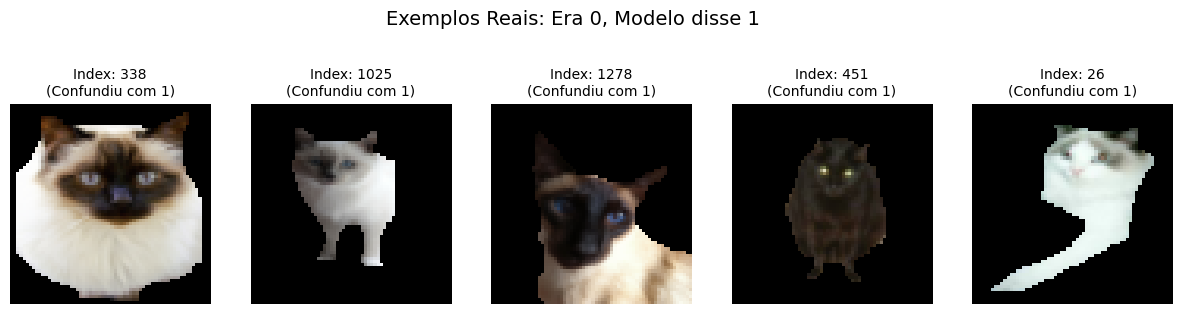

Analisando confusão: Real '1' -> Predito '0'
Total de imagens nessa célula: 59


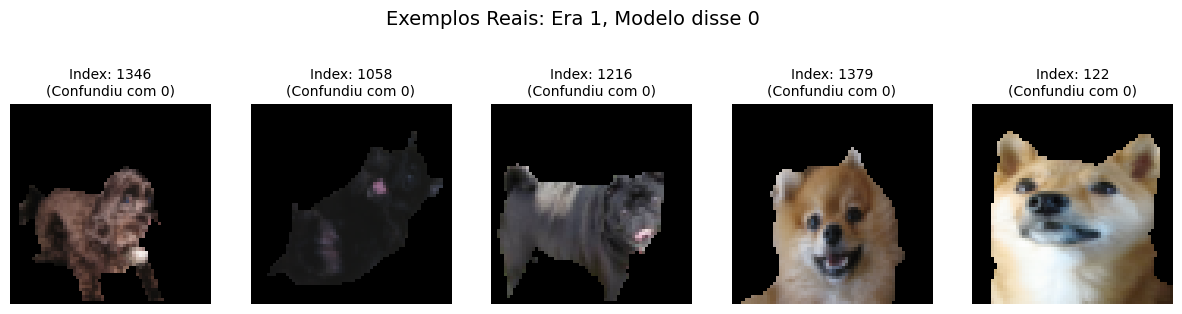

Analisando confusão: Real '0' -> Predito '0'
Total de imagens nessa célula: 148


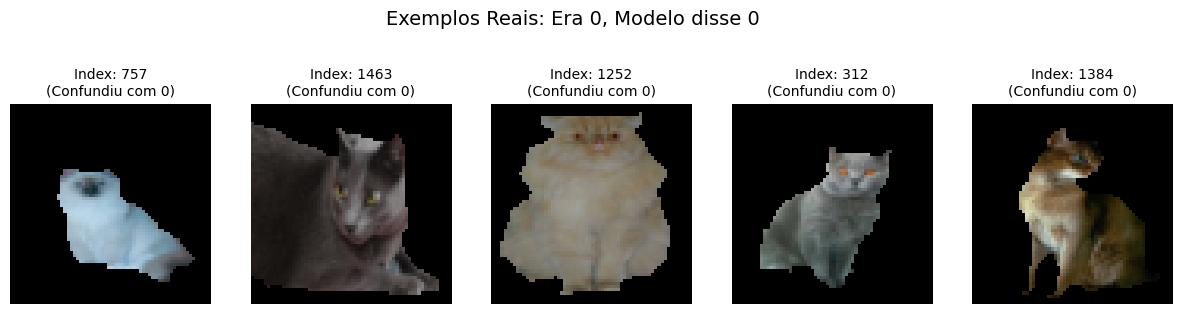

Analisando confusão: Real '1' -> Predito '1'
Total de imagens nessa célula: 944


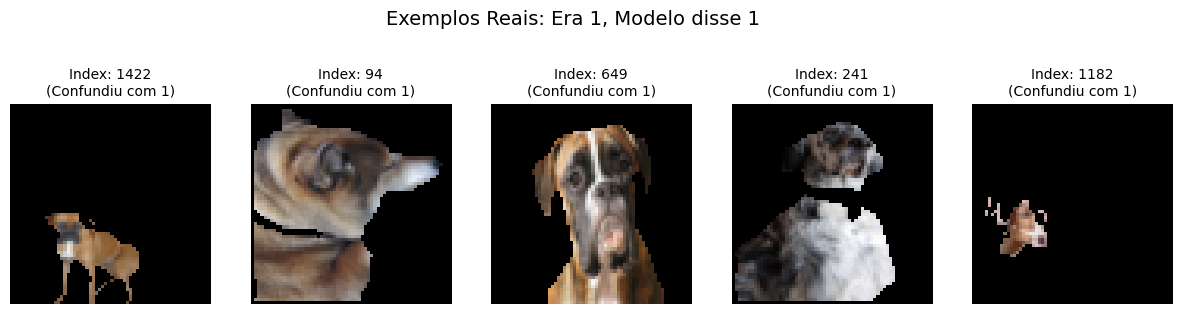

In [ ]:
# --- COMO USAR ---

# Exemplo 1: Se seus dados forem binários (0=Gato, 1=Cão)
# Quero ver Gatos (0) que o modelo achou que eram Cães (1) -> Falso Positivo
visualizar_erro_matriz(classe_real=0, classe_predita=1,X_test= X_test_mask, y_test=y_test_mask, y_pred = y_pred_mask)
visualizar_erro_matriz(classe_real=1, classe_predita=0,X_test= X_test_mask, y_test=y_test_mask, y_pred = y_pred_mask)
visualizar_erro_matriz(classe_real=0, classe_predita=0,X_test= X_test_mask, y_test=y_test_mask, y_pred = y_pred_mask)
visualizar_erro_matriz(classe_real=1, classe_predita=1,X_test= X_test_mask, y_test=y_test_mask, y_pred = y_pred_mask)

# Exemplo 2: Se seus dados forem nomes de raças (Strings)
# Quero ver Abissínios que o modelo achou que eram Beagles
# visualizar_erro_matriz(classe_real='Abyssinian', classe_predita='Beagle')

# **TESTE BINARIO: random erase**

In [ ]:
X_train_re = X_train_mask
X_test_re = X_test_mask
y_train_re = y_train_mask
y_test_re = y_test_mask

X_lista = list(X_train_re)
y_lista = list(y_train_re)

# Quantas novas imagens você quer criar? (Aqui mantive seu 1/3)
total_atual = len(X_lista)
qnt_novas = total_atual
#qnt_novas = int(total_atual / 3)

print(f"Gerando {qnt_novas} novas imagens com Random Erasing...")

for i in range(qnt_novas):
    indice = np.random.randint(0, total_atual)
    img_copy = X_lista[indice].copy()
    img_aug_flat = random_erasing_treino(img_copy, p=1.0)
    X_lista.append(img_aug_flat)
    y_lista.append(y_lista[indice])


X_train_re = np.array(X_lista)
y_train_re = np.array(y_lista)

print(f"Dataset aumentado! Antes: {total_atual}, Agora: {len(X_train_re)}")

print("Valores únicos no y_test:", np.unique(y_test_mask))
print("Matriz de features do dataset de treino:\tformato ", X_train_re.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train_re.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test_re.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test_re.shape)

Gerando 5876 novas imagens com Random Erasing...
Dataset aumentado! Antes: 5876, Agora: 11752
Valores únicos no y_test: [0 1]
Matriz de features do dataset de treino:	formato  (11752, 12288)
Vetor de labels do dataset de treino:		formato  (11752,)
Matriz de features do dataset de teste:		formato  (1470, 12288)
Vetor de labels do dataset de teste:		formato  (1470,)


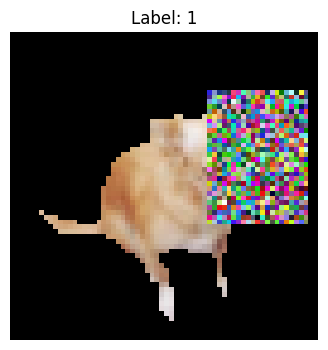

In [ ]:
# 1. Pegue uma imagem processada aleatória
index = random.randint(0, len(X_train_re) - 1)
imagem_vetor = X_train_re[index]
label = y_train_re[index]


img_reconstruida = imagem_vetor.reshape(dim, dim, 3)

if img_reconstruida.max() <= 1.5:
    img_reconstruida = img_reconstruida * 255

# 5. Converte para Inteiro (pra o gráfico não ficar estranho)
img_final = np.clip(img_reconstruida, 0, 255).astype(np.uint8)

# 6. Plotar
plt.figure(figsize=(4,4))
plt.imshow(img_final)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

treinamento random forest

In [ ]:
rf_re = RandomForestClassifier(n_estimators=100,
                            max_depth=None,
                            n_jobs=-1,
                            random_state=42,
                            class_weight='balanced' # balanceamento dos pesos para tentar driblar o desbalanceio das especies
                           )
rf_re.fit(X_train_re, y_train_re)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
# --- PREVISÃO ---
print("Fazendo previsões...")
y_pred_re = rf_re.predict(X_test_re)

# --- RESULTADOS ---
print(f"Acurácia: {accuracy_score(y_test_re, y_pred_re)*100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test_re, y_pred_re, target_names=['Gato (0)', 'Cachorro (1)']))

Fazendo previsões...
Acurácia: 74.49%

Relatório Detalhado:
              precision    recall  f1-score   support

    Gato (0)       0.69      0.35      0.47       467
Cachorro (1)       0.75      0.93      0.83      1003

    accuracy                           0.74      1470
   macro avg       0.72      0.64      0.65      1470
weighted avg       0.74      0.74      0.72      1470



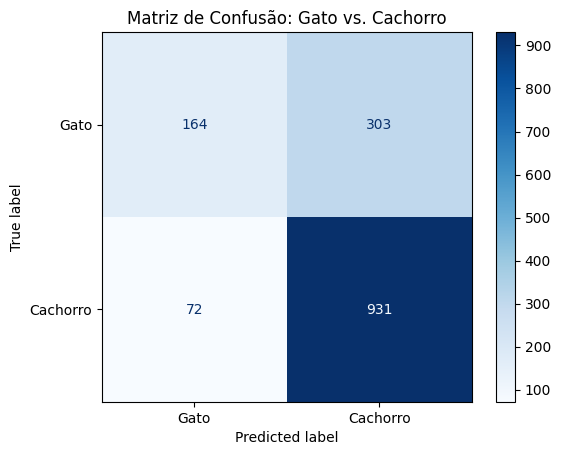

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_re,
    y_pred_re,
    display_labels=['Gato', 'Cachorro'],
    cmap='Blues'
)

plt.title("Matriz de Confusão: Gato vs. Cachorro")
plt.grid(False)
plt.show()

In [ ]:
y_probas_forest_re = cross_val_predict(rf_re, X_train_re, y_train_re,
                                    cv=3, method="predict_proba")

y_scores_forest_re = y_probas_forest_re[:, 1]
precisions_forest_re, recalls_forest_re, thresholds_forest_re = precision_recall_curve(y_train_re, y_scores_forest_re)

roc_auc_re = roc_auc_score(y_train_re, y_scores_forest_re)
print("ROC AUC:%.4f"%roc_auc_re)

fpr_forest_re, tpr_forest_re, thresholds_re = roc_curve(y_train_re, y_scores_forest_re)

ROC AUC:0.9195


Analisando confusão: Real '0' -> Predito '1'
Total de imagens nessa célula: 303


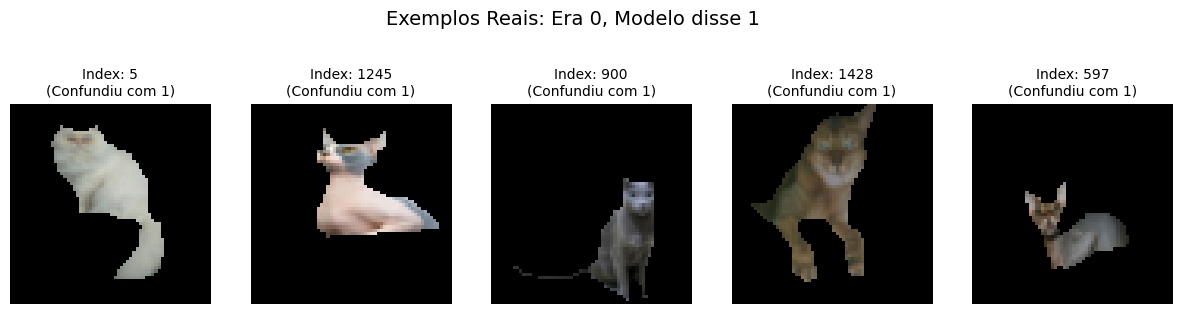

Analisando confusão: Real '1' -> Predito '0'
Total de imagens nessa célula: 72


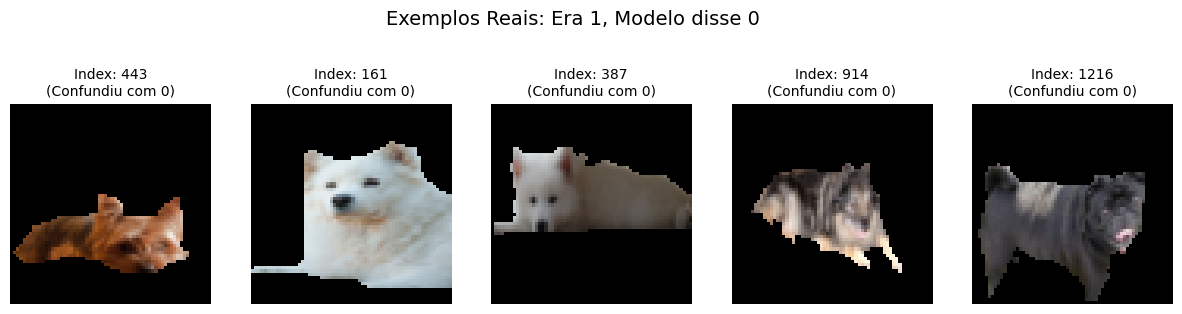

Analisando confusão: Real '0' -> Predito '0'
Total de imagens nessa célula: 164


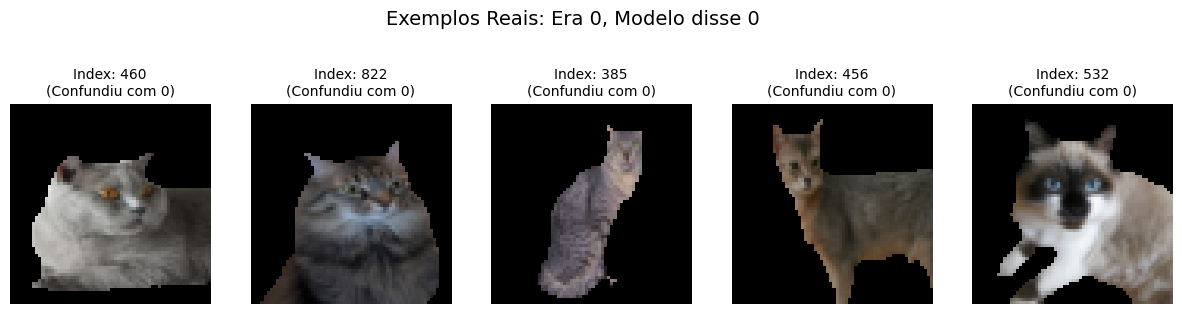

Analisando confusão: Real '1' -> Predito '1'
Total de imagens nessa célula: 931


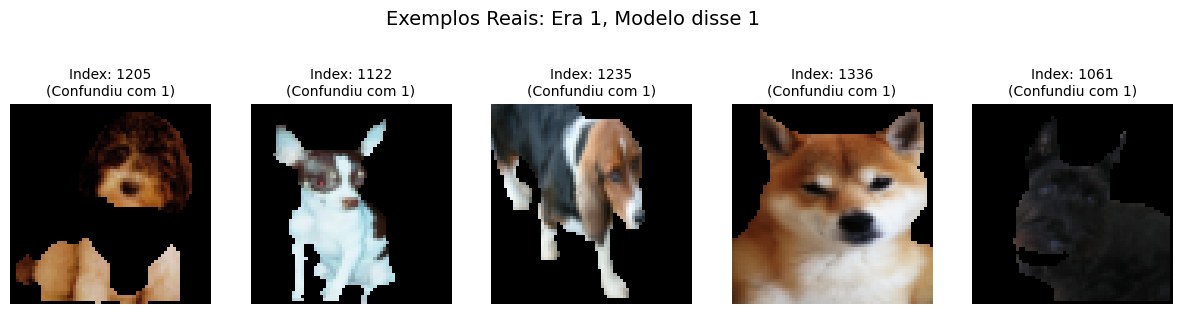

In [ ]:
visualizar_erro_matriz(classe_real=0, classe_predita=1,X_test= X_test_re, y_test=y_test_re, y_pred = y_pred_re)
visualizar_erro_matriz(classe_real=1, classe_predita=0,X_test= X_test_re, y_test=y_test_re, y_pred = y_pred_re)
visualizar_erro_matriz(classe_real=0, classe_predita=0,X_test= X_test_re, y_test=y_test_re, y_pred = y_pred_re)
visualizar_erro_matriz(classe_real=1, classe_predita=1,X_test= X_test_re, y_test=y_test_re, y_pred = y_pred_re)

# limpeza de variaveis


In [ ]:

# del  X_test, y_test, y_pred, X_train, y_train, X, y
# del  X_up, y_up,X_test_up, y_test_up, y_pred_up, X_train_up, y_train_up, rf_up
# del  X_tri_concat,y_tri_concat, X_train_concat, X_test_concat, y_train_concat, y_test_concat,rf_concat
# del  X_test_re, y_test_re, y_pred_re, X_train_re, y_train_re, X_re, y_re

# **classificação multiclasse baseline**

In [ ]:
def data_species_masking_multiclasse(dim, base_dir, trimap_dir, df):
    data_x = []
    data_y = []

    print("Iniciando processamento com Mascaramento (Recorte)...")

    for index, row in df.iterrows():
        try:

            img_path = os.path.join(base_dir, row['filename'])
            filename_png = row['filename'].replace('.jpg', '.png')
            trimap_path = os.path.join(trimap_dir, filename_png)

            img = imread(img_path)
            trimap = imread(trimap_path, as_gray=True)


            img_resized = resize(img, (dim, dim), anti_aliasing=True, mode='reflect')
            trimap_resized = resize(trimap, (dim, dim), order=0, preserve_range=True, mode='reflect')


            mascara = np.where(trimap_resized == 1, 1, 0) # 1 onde é animal, 0 onde é fundo

            # 4. Expandir máscara para 3 canais (RGB)
            mascara_rgb = np.stack((mascara, mascara, mascara), axis=2)

            # 5. MÁGICA: Multiplicação (Recorte)
            # Onde a máscara é 0, a imagem vira preto.
            img_recortada = img_resized * mascara_rgb

            # 6. Achatar e Salvar
            img_flat = img_recortada.flatten()

            if len(img_flat) == dim * dim * 3:
                data_x.append(img_flat)
                data_y.append(row['class_id'])

        except Exception as e:
            print(f"Erro ao processar {row['filename']}: {e}")

    return np.array(data_x), np.array(data_y)




In [ ]:
X_mask_mc,y_mask_mc = data_species_masking_multiclasse(dim,base_dir,trimap_dir,df)
print(X_mask_mc.shape)
print(y_mask_mc.shape)
print(X_mask_mc[1])

Iniciando processamento com Mascaramento (Recorte)...
Erro ao processar Egyptian_Mau_14.jpg: operands could not be broadcast together with shapes (64,64,4) (64,64,3) 
Erro ao processar Egyptian_Mau_186.jpg: operands could not be broadcast together with shapes (64,64,4) (64,64,3) 
Erro ao processar Abyssinian_5.jpg: operands could not be broadcast together with shapes (64,64,4) (64,64,3) 
(7346, 12288)
(7346,)
[0. 0. 0. ... 0. 0. 0.]


In [ ]:
X_train_mask_mc, X_test_mask_mc, y_train_mask_mc, y_test_mask_mc = train_test_split(X_mask_mc,y_mask_mc,
                                       test_size=0.2, # parâmetro da divisão 80/20
                                       random_state=42)


print("Valores únicos no y_test:", np.unique(y_test_mask_mc))
print("Valores únicos no y_train:", np.unique(y_train_mask_mc))
print("Matriz de features do dataset de treino:\tformato ", X_train_mask_mc.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train_mask_mc.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test_mask_mc.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test_mask_mc.shape)

Valores únicos no y_test: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37]
Valores únicos no y_train: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37]
Matriz de features do dataset de treino:	formato  (5876, 12288)
Vetor de labels do dataset de treino:		formato  (5876,)
Matriz de features do dataset de teste:		formato  (1470, 12288)
Vetor de labels do dataset de teste:		formato  (1470,)


In [ ]:
rf_mask_mc = RandomForestClassifier(n_estimators=100,
                            max_depth=None,
                            n_jobs=-1,
                            random_state=42,
                            class_weight='balanced' # balanceamento dos pesos para tentar driblar o desbalanceio das especies
                           )
rf_mask_mc.fit(X_train_mask_mc, y_train_mask_mc)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# --- PREVISÃO ---
print("Fazendo previsões...")
y_pred_mask_mc = rf_mask_mc.predict(X_test_mask_mc)

# --- RESULTADOS ---
print(f"Acurácia: {accuracy_score(y_test_mask_mc, y_pred_mask_mc)*100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test_mask_mc, y_pred_mask_mc))


Fazendo previsões...
Acurácia: 14.69%

Relatório Detalhado:
              precision    recall  f1-score   support

           1       0.12      0.14      0.13        43
           2       0.12      0.08      0.10        50
           3       0.00      0.00      0.00        37
           4       0.12      0.10      0.11        41
           5       0.08      0.13      0.10        31
           6       0.13      0.19      0.15        37
           7       0.14      0.16      0.15        37
           8       0.27      0.48      0.35        29
           9       0.15      0.11      0.12        38
          10       0.17      0.26      0.21        43
          11       0.09      0.04      0.05        50
          12       0.13      0.21      0.16        34
          13       0.14      0.06      0.08        36
          14       0.07      0.06      0.06        36
          15       0.18      0.18      0.18        45
          16       0.14      0.23      0.17        39
          17       0.

Total de nomes extraídos: 37


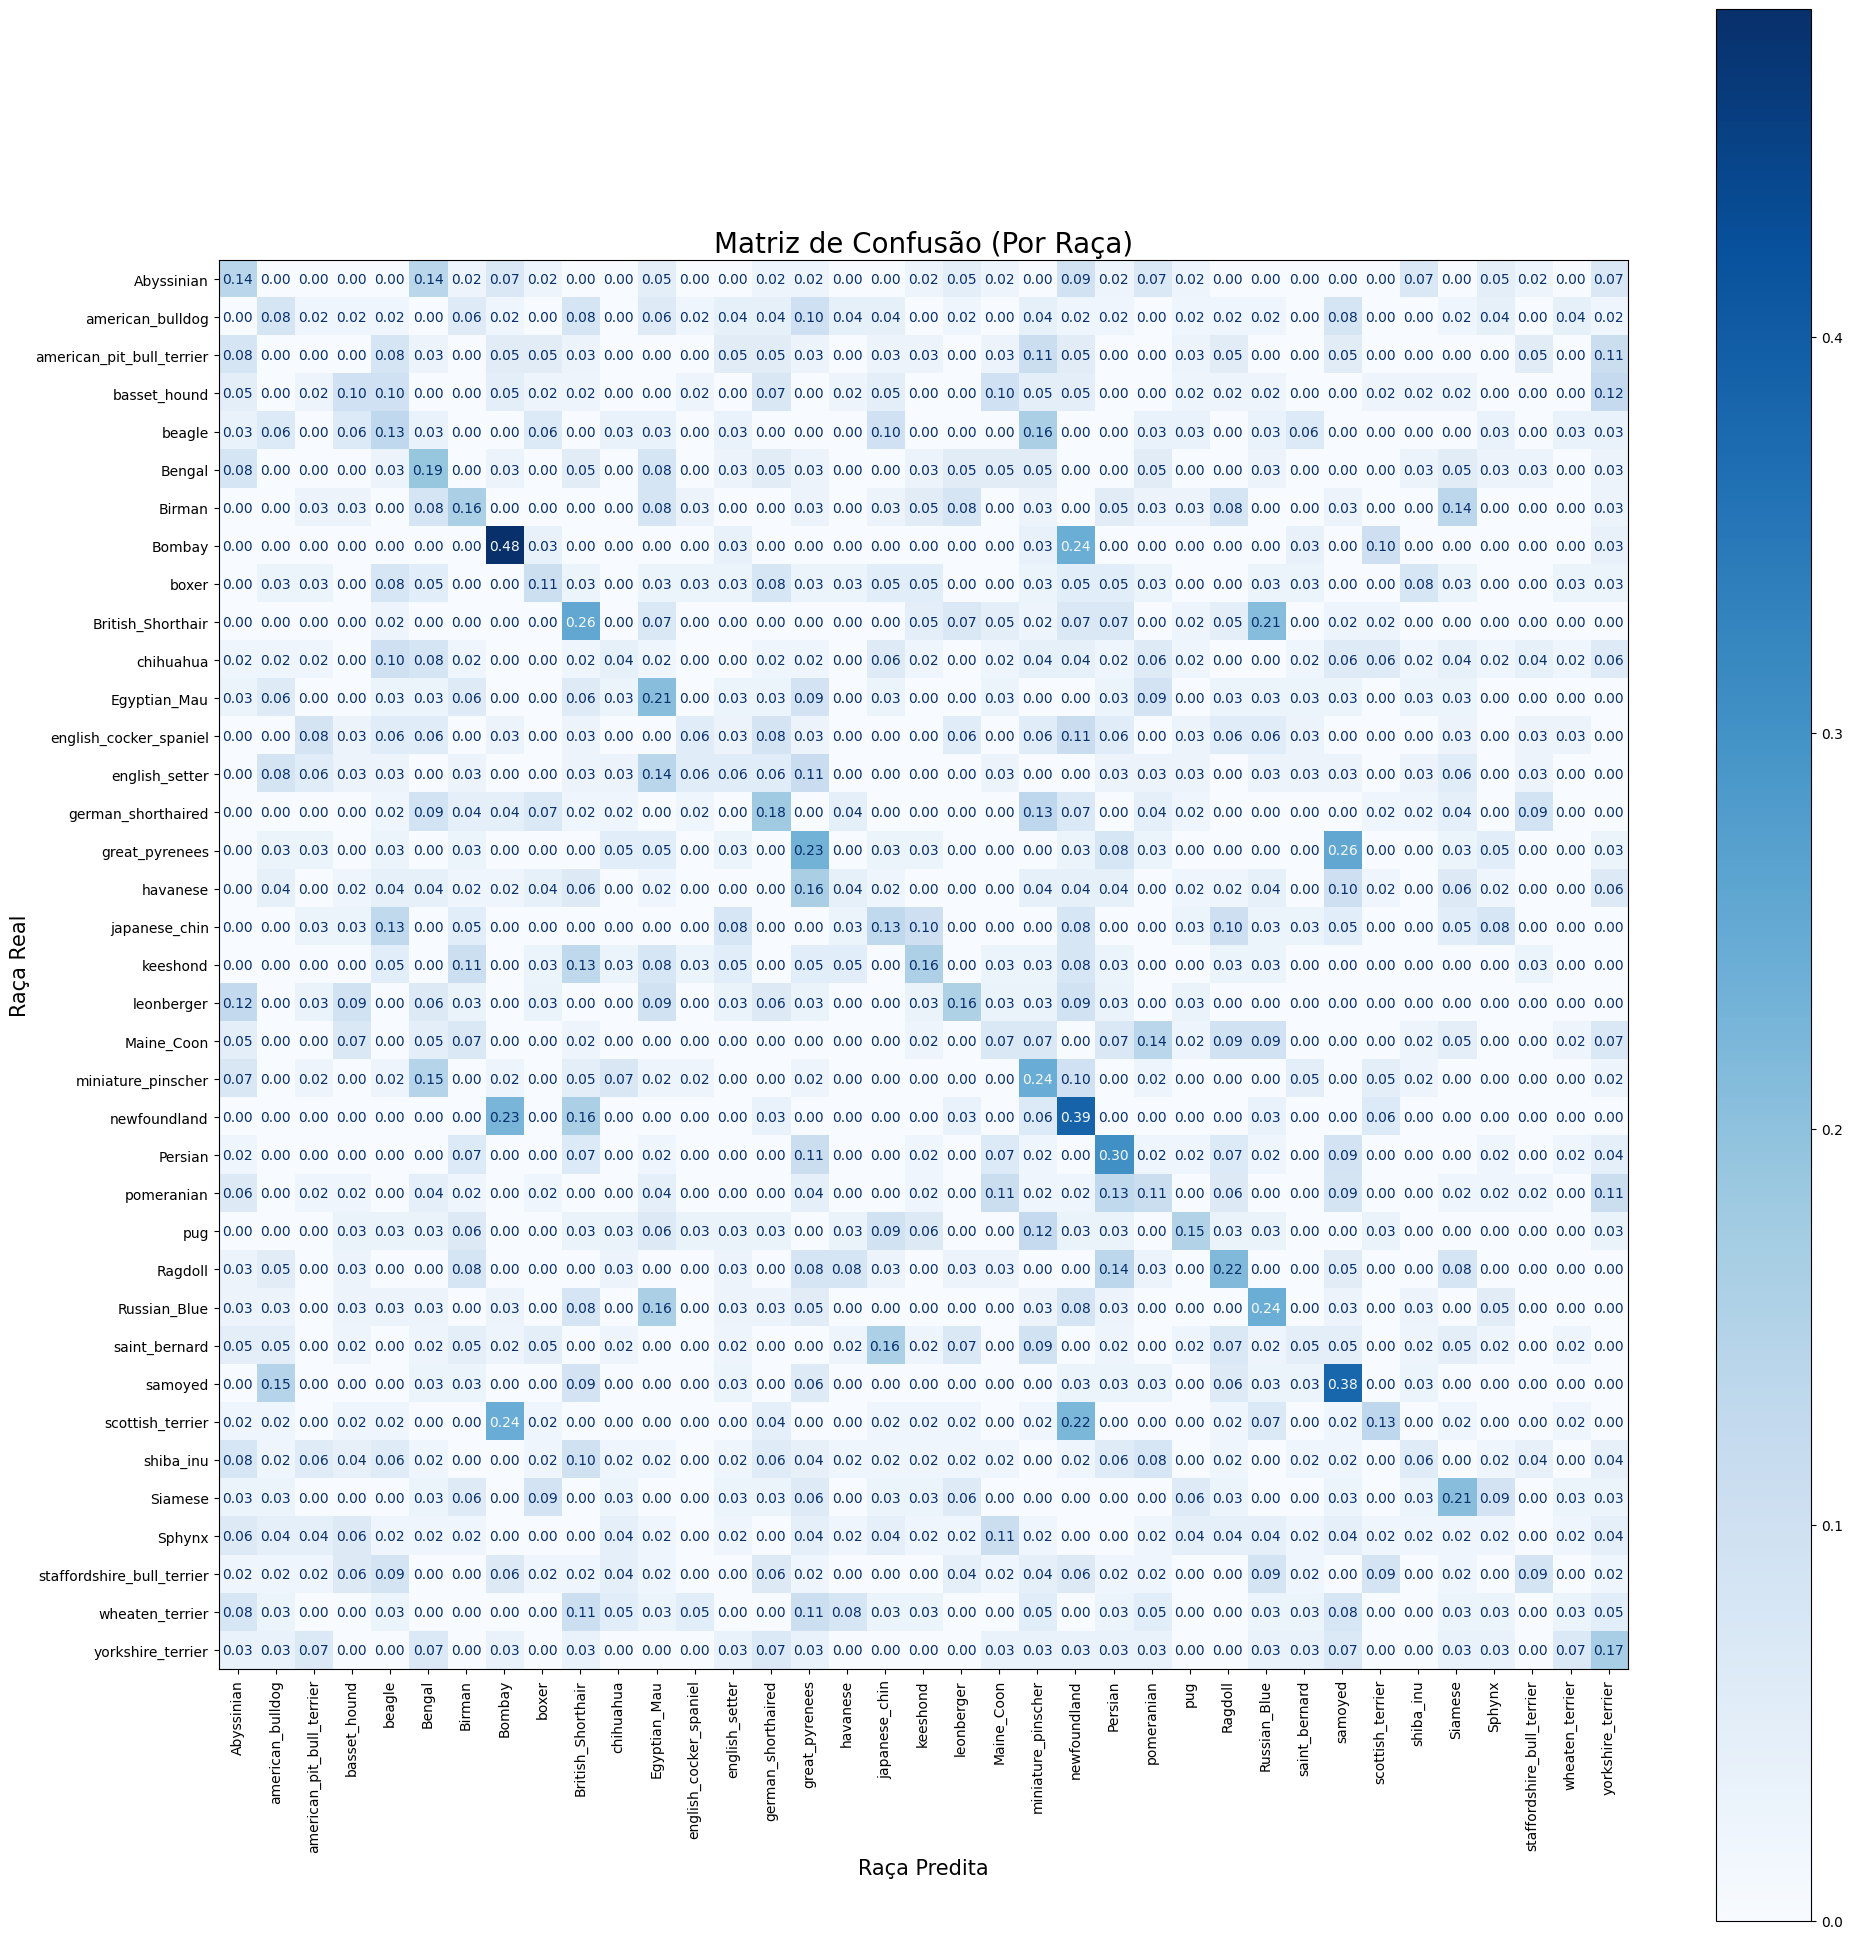

In [ ]:
# 1. Criar um dicionário ordenado para garantir que o ID 1 seja a raça certa
# O filename é algo como "Abyssinian_100.jpg", queremos só "Abyssinian"
df['breed_name'] = df['filename'].apply(lambda x: x.rpartition('_')[0])

# Criamos uma lista ordenada pelos class_ids (1, 2, 3...)
# drop_duplicates garante que pegamos o nome apenas uma vez por ID
mapa_nomes = df[['class_id', 'breed_name']].drop_duplicates().sort_values('class_id')
lista_nomes = mapa_nomes['breed_name'].tolist()

print(f"Total de nomes extraídos: {len(lista_nomes)}")

# Aumentar drasticamente o tamanho da figura para caber 37 classes
fig, ax = plt.subplots(figsize=(20, 20))

# Plotar
ConfusionMatrixDisplay.from_predictions(
    y_test_mask_mc,    # Seus dados reais (use as variáveis certas do seu código)
    y_pred_mask_mc,    # Suas previsões
    display_labels=lista_nomes, # AQUI ENTRA A MÁGICA (os nomes)
    ax=ax,
    cmap='Blues',      # 'Reds' ou 'Viridis' também funcionam bem
    normalize='true',  # Mostra PORCENTAGEM (0 a 1) em vez de contagem absoluta
    xticks_rotation='vertical', # Vira os nomes de baixo para caberem
    values_format='.2f' # Mostra apenas 1 casa decimal (ex: 0.9 em vez de 0.92312)
)

plt.title("Matriz de Confusão (Por Raça)", fontsize=20)
plt.xlabel("Raça Predita", fontsize=15)
plt.ylabel("Raça Real", fontsize=15)

# Ajuste fino para não cortar os textos na hora de salvar/mostrar
plt.tight_layout()
plt.show()

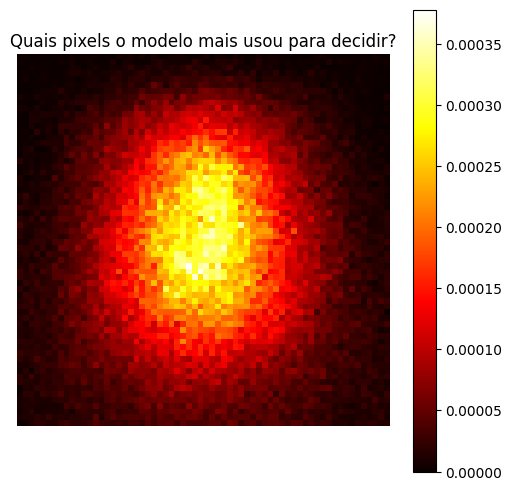

In [ ]:
importances = rf_mask_mc.feature_importances_

# Redimensiona de volta para o formato da imagem (64x64x3)
# Tira a média dos 3 canais de cor para ficar uma imagem de calor 2D
heatmap = importances.reshape(dim, dim, 3).mean(axis=2)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap='hot')
plt.title("Quais pixels o modelo mais usou para decidir?")
plt.colorbar()
plt.axis('off')
plt.show()

Total de acertos disponíveis para escolha: 216


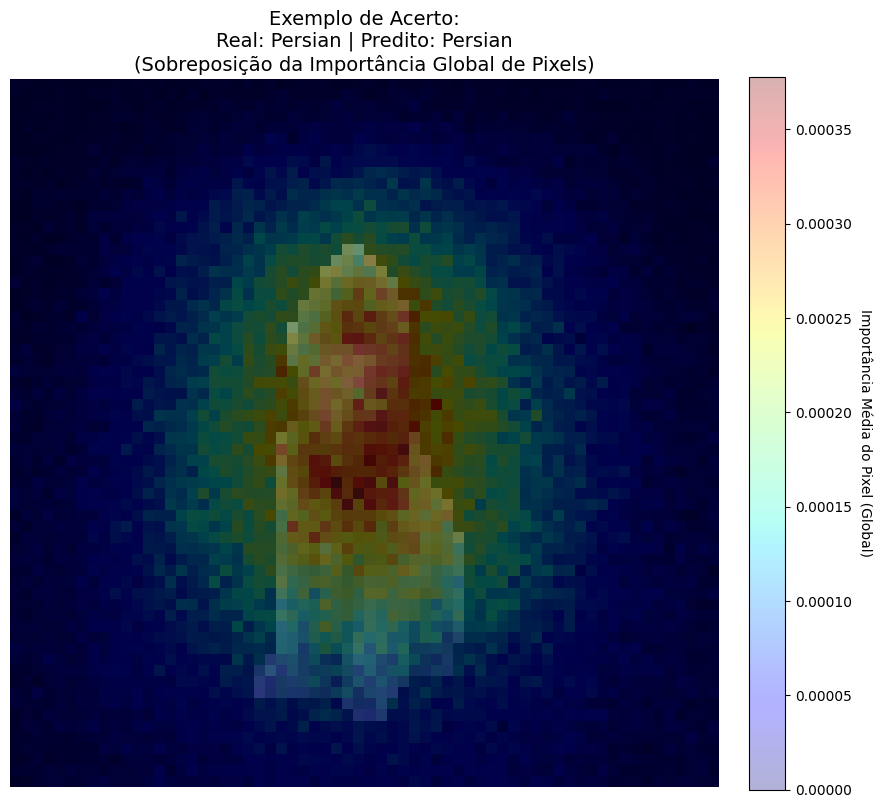

In [ ]:
# --- PASSO 1: Calcular o Heatmap Global ---
# Pega a importância de cada um dos 12288 pixels
importances = rf_mask_mc.feature_importances_


indices_acertos = np.where(y_test_mask_mc == y_pred_mask_mc)[0]
heatmap = importances.reshape(dim, dim, 3).mean(axis=2)


print(f"Total de acertos disponíveis para escolha: {len(indices_acertos)}")


indice_sorteado = np.random.choice(indices_acertos)

# --- PASSO 4: Recuperar e Reconstruir a Imagem ---
img_flat = X_test_mask_mc[indice_sorteado]
label_real_idx = y_test_mask_mc[indice_sorteado]
label_pred_idx = y_pred_mask_mc[indice_sorteado]

# Tenta pegar o nome da raça se a lista existir, senão usa o número ID
try:
    # Assumindo que seus labels agora são índices de 0 a 36 para usar na lista
    nome_real = lista_nomes[label_real_idx]
    nome_predito = lista_nomes[label_pred_idx]
except NameError:
    nome_real = str(label_real_idx)
    nome_predito = str(label_pred_idx)
except IndexError:
    # Caso seus labels ainda sejam de 1 a 37, ajusta o índice
    nome_real = lista_nomes[label_real_idx - 1]
    nome_predito = lista_nomes[label_pred_idx - 1]

# Reshape de 1D para 3D
img_rgb = img_flat.reshape(dim, dim, 3)

# Desnormalizar (converter de 0.0-1.0 float para 0-255 uint8)
# Se sua imagem já estiver em 0-255, remova a multiplicação por 255
img_final = (img_rgb * 255).astype(np.uint8)


# --- PASSO 5: Plotar com Sobreposição ---
fig, ax = plt.subplots(figsize=(10, 10))

# Camada de fundo: A imagem real do animal
ax.imshow(img_final)

# Camada superior: O mapa de calor global
# alpha=0.6 define a transparência (0.0 invisível, 1.0 sólido)
# cmap='jet' usa cores fortes (azul=frio/pouco importante, vermelho=quente/muito importante)
sobreposicao = ax.imshow(heatmap, cmap='jet', alpha=0.3)

# Títulos e legendas
ax.set_title(f"Exemplo de Acerto:\nReal: {nome_real} | Predito: {nome_predito}\n(Sobreposição da Importância Global de Pixels)", fontsize=14)
ax.axis('off')

# Barra de cores para entender a escala do heatmap
cbar = plt.colorbar(sobreposicao, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Importância Média do Pixel (Global)', rotation=270, labelpad=15)

plt.show()

In [ ]:
y_probas = cross_val_predict(rf_mask_mc, X_train_mask_mc, y_train_mask_mc,
                             cv=3, method="predict_proba")

# 'ovr': Compara cada classe contra todas as outras e tira a média
roc_auc = roc_auc_score(y_train_mask_mc, y_probas, multi_class='ovr', average='weighted')
print(f"ROC AUC (Weighted OvR): {roc_auc:.4f}")

ROC AUC (Weighted OvR): 0.7365


# **multiclasse: random forest com random erasing**

In [ ]:
X_train_re_mc = X_train_mask_mc
X_test_re_mc = X_test_mask_mc
y_train_re_mc = y_train_mask_mc
y_test_re_mc = y_test_mask_mc

X_lista = list(X_train_re_mc)
y_lista = list(y_train_re_mc)

total_atual = len(X_lista)
qnt_novas = total_atual
#qnt_novas = int(total_atual / 3)

print(f"Gerando {qnt_novas} novas imagens com Random Erasing...")

for i in range(qnt_novas):
    indice = np.random.randint(0, total_atual)
    img_copy = X_lista[indice].copy()
    img_aug_flat = random_erasing_treino(img_copy, p=1.0)
    X_lista.append(img_aug_flat)
    y_lista.append(y_lista[indice])


X_train_re_mc = np.array(X_lista)
y_train_re_mc = np.array(y_lista)

print(f"Dataset aumentado! Antes: {total_atual}, Agora: {len(X_train_re_mc)}")
print("Valores únicos no y_test:", np.unique(y_test_mask_mc))
print("Matriz de features do dataset de treino:\tformato ", X_train_re_mc.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train_re_mc.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test_re_mc.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test_re_mc.shape)

Gerando 5876 novas imagens com Random Erasing...
Dataset aumentado! Antes: 5876, Agora: 11752
Valores únicos no y_test: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37]
Matriz de features do dataset de treino:	formato  (11752, 12288)
Vetor de labels do dataset de treino:		formato  (11752,)
Matriz de features do dataset de teste:		formato  (1470, 12288)
Vetor de labels do dataset de teste:		formato  (1470,)


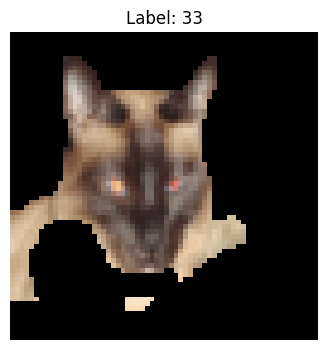

In [ ]:
# 1. Pegue uma imagem processada aleatória
index = random.randint(0, len(X_train_re_mc) - 1)
imagem_vetor = X_train_re_mc[index]
label = y_train_re_mc[index]


img_reconstruida = imagem_vetor.reshape(dim, dim, 3)

if img_reconstruida.max() <= 1.5:
    img_reconstruida = img_reconstruida * 255

# 5. Converte para Inteiro (pra o gráfico não ficar estranho)
img_final = np.clip(img_reconstruida, 0, 255).astype(np.uint8)

# 6. Plotar
plt.figure(figsize=(4,4))
plt.imshow(img_final)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [ ]:
rf_re_mc = RandomForestClassifier(n_estimators=100,
                            max_depth=None,
                            n_jobs=-1,
                            random_state=42,
                            class_weight='balanced' # balanceamento dos pesos para tentar driblar o desbalanceio das especies
                           )
rf_re_mc.fit(X_train_re_mc, y_train_re_mc)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# --- PREVISÃO ---
print("Fazendo previsões...")
y_pred_re_mc = rf_re_mc.predict(X_test_re_mc)

# --- RESULTADOS ---
print(f"Acurácia: {accuracy_score(y_test_re_mc, y_pred_re_mc)*100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test_re_mc, y_pred_re_mc))


Fazendo previsões...
Acurácia: 13.40%

Relatório Detalhado:
              precision    recall  f1-score   support

           1       0.08      0.09      0.09        43
           2       0.14      0.08      0.10        50
           3       0.03      0.03      0.03        37
           4       0.06      0.05      0.05        41
           5       0.00      0.00      0.00        31
           6       0.11      0.22      0.14        37
           7       0.12      0.14      0.12        37
           8       0.33      0.66      0.44        29
           9       0.12      0.11      0.11        38
          10       0.13      0.16      0.15        43
          11       0.11      0.04      0.06        50
          12       0.19      0.29      0.23        34
          13       0.00      0.00      0.00        36
          14       0.12      0.08      0.10        36
          15       0.15      0.13      0.14        45
          16       0.16      0.21      0.18        39
          17       0.

Total de nomes extraídos: 37


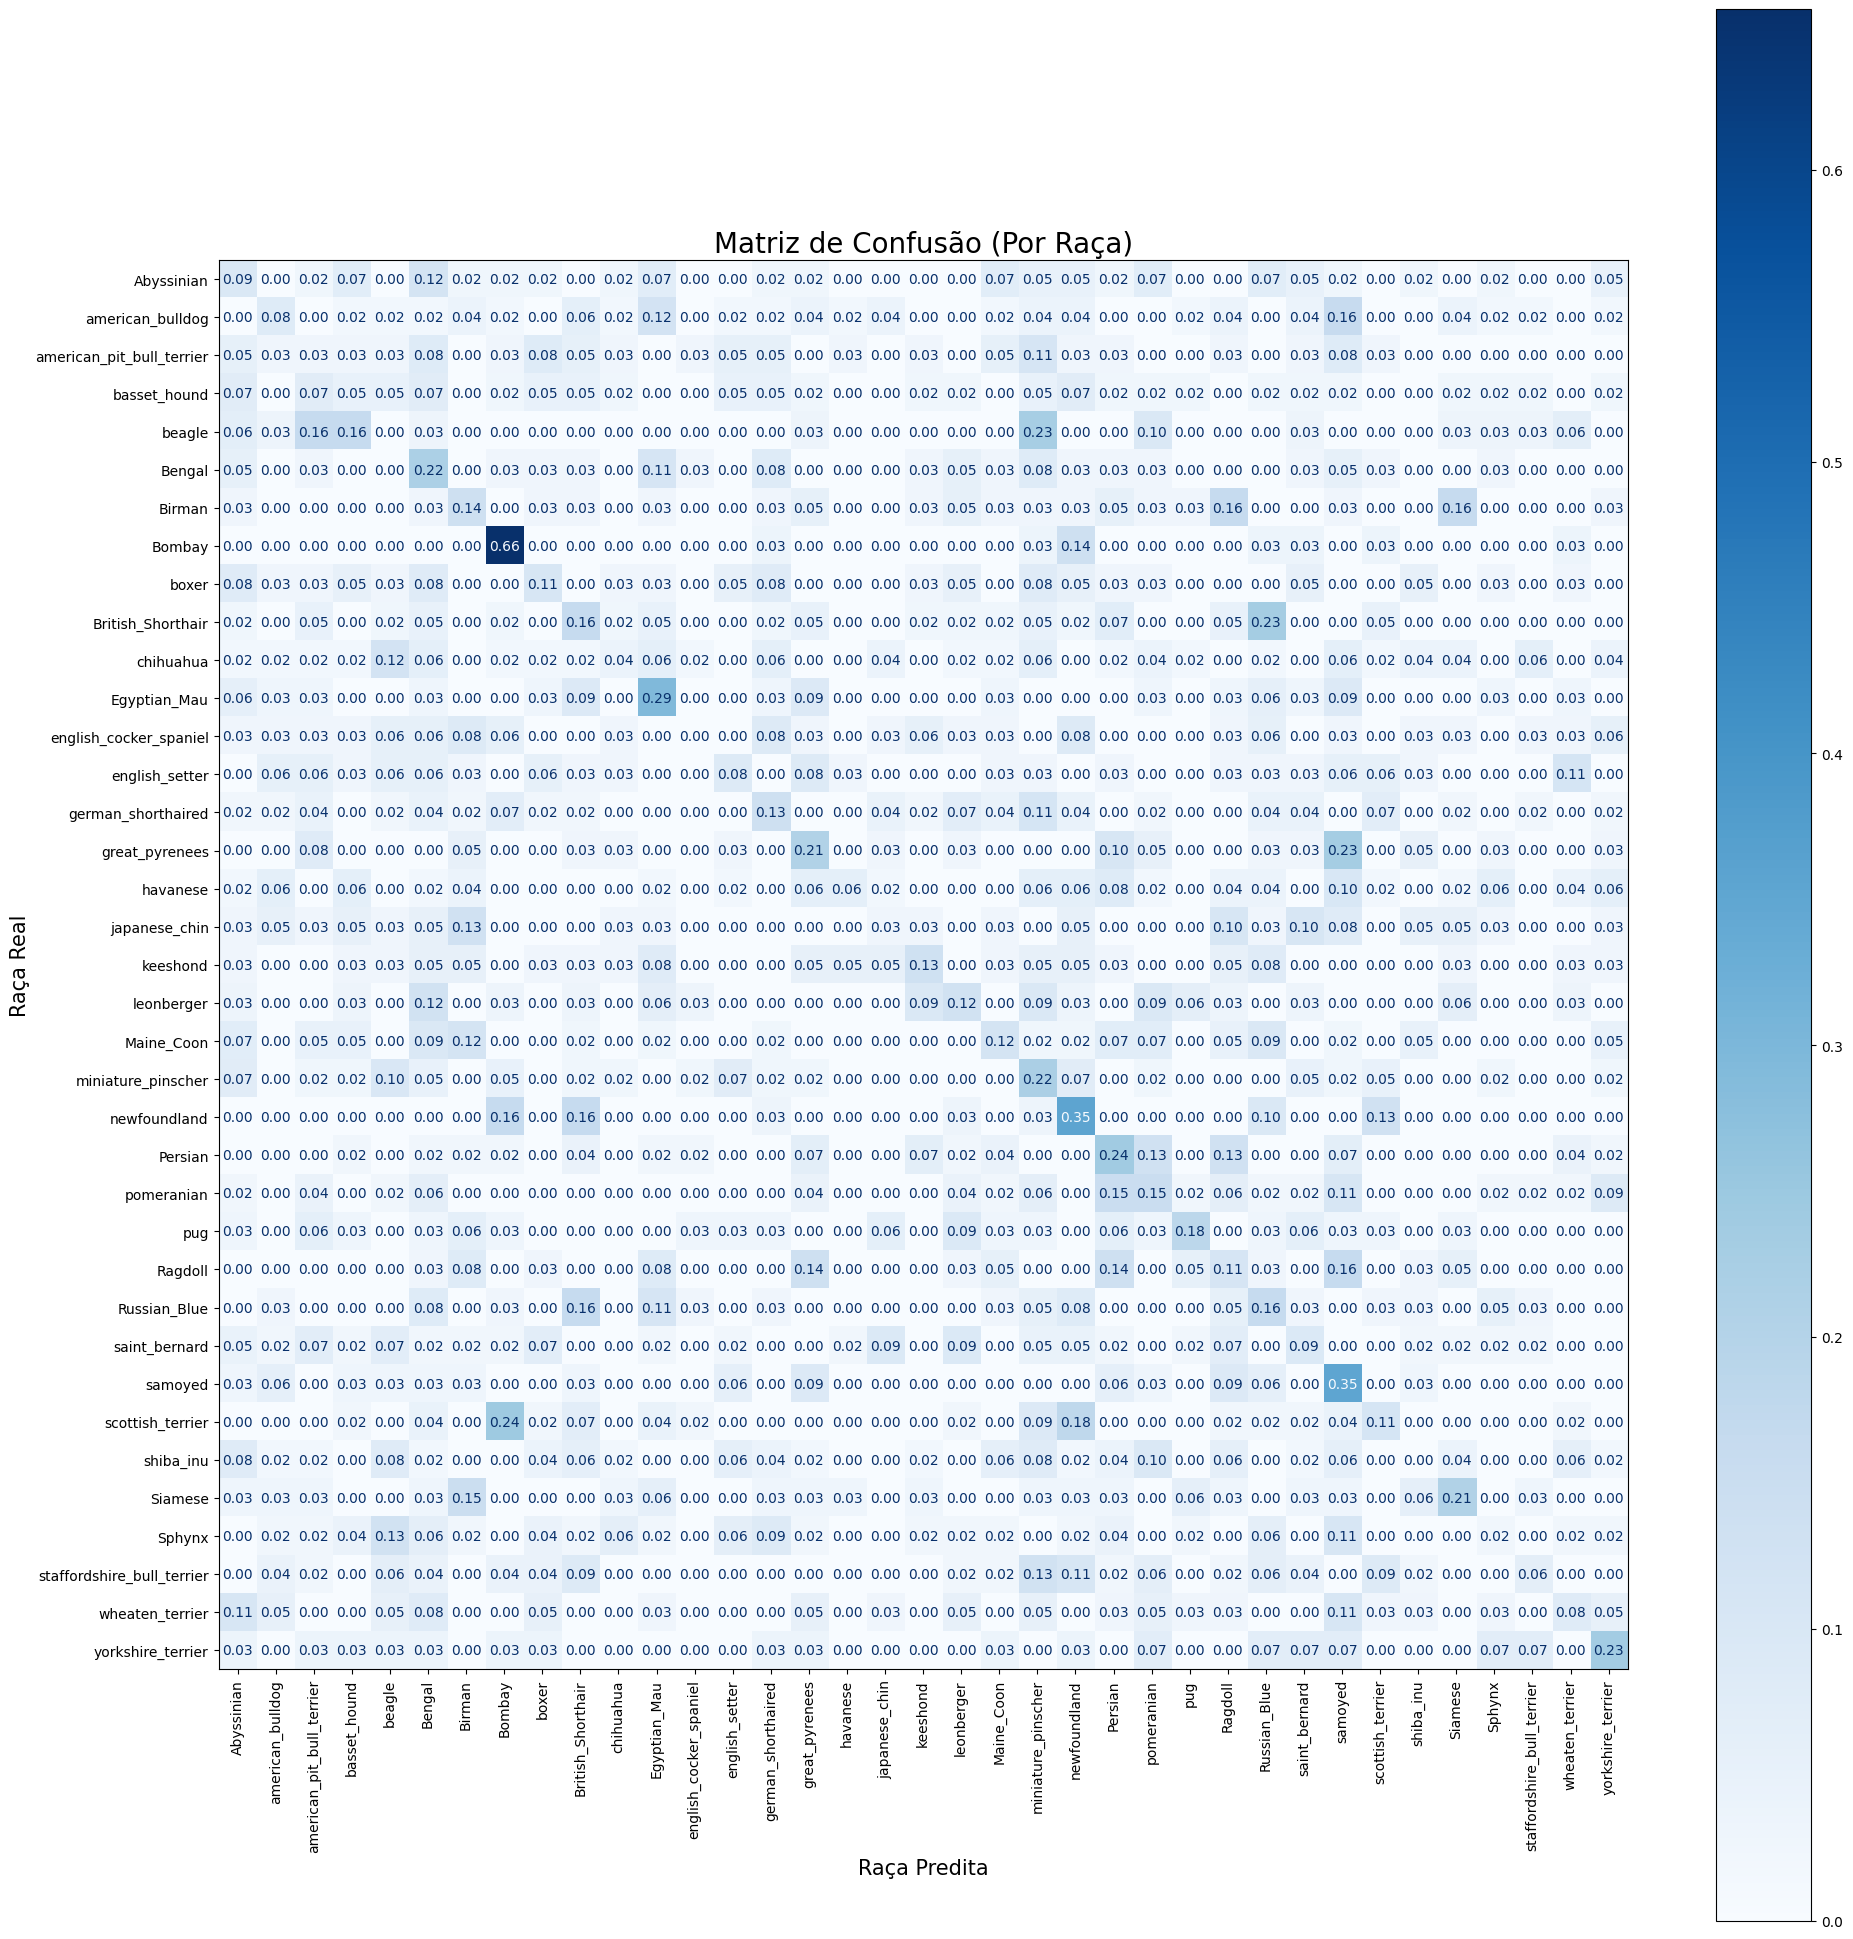

In [ ]:
# 1. Criar um dicionário ordenado para garantir que o ID 1 seja a raça certa
# O filename é algo como "Abyssinian_100.jpg", queremos só "Abyssinian"
df['breed_name'] = df['filename'].apply(lambda x: x.rpartition('_')[0])

# Criamos uma lista ordenada pelos class_ids (1, 2, 3...)
# drop_duplicates garante que pegamos o nome apenas uma vez por ID
mapa_nomes = df[['class_id', 'breed_name']].drop_duplicates().sort_values('class_id')
lista_nomes = mapa_nomes['breed_name'].tolist()

print(f"Total de nomes extraídos: {len(lista_nomes)}")

# Aumentar drasticamente o tamanho da figura para caber 37 classes
fig, ax = plt.subplots(figsize=(20, 20))

# Plotar
ConfusionMatrixDisplay.from_predictions(
    y_test_re_mc,    # Seus dados reais (use as variáveis certas do seu código)
    y_pred_re_mc,    # Suas previsões
    display_labels=lista_nomes, # AQUI ENTRA A MÁGICA (os nomes)
    ax=ax,
    cmap='Blues',      # 'Reds' ou 'Viridis' também funcionam bem
    normalize='true',  # Mostra PORCENTAGEM (0 a 1) em vez de contagem absoluta
    xticks_rotation='vertical', # Vira os nomes de baixo para caberem
    values_format='.2f' # Mostra apenas 1 casa decimal (ex: 0.9 em vez de 0.92312)
)

plt.title("Matriz de Confusão (Por Raça)", fontsize=20)
plt.xlabel("Raça Predita", fontsize=15)
plt.ylabel("Raça Real", fontsize=15)

# Ajuste fino para não cortar os textos na hora de salvar/mostrar
plt.tight_layout()
plt.show()

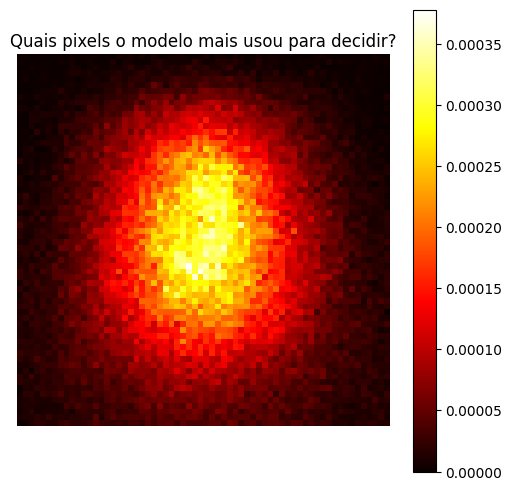

In [ ]:
importances = rf_mask_mc.feature_importances_

# Redimensiona de volta para o formato da imagem (64x64x3)
# Tira a média dos 3 canais de cor para ficar uma imagem de calor 2D
heatmap = importances.reshape(dim, dim, 3).mean(axis=2)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap='hot')
plt.title("Quais pixels o modelo mais usou para decidir?")
plt.colorbar()
plt.axis('off')
plt.show()

In [ ]:
y_probas = cross_val_predict(rf_mask_mc, X_train_mask_mc, y_train_mask_mc,
                             cv=3, method="predict_proba")

# 'ovr': Compara cada classe contra todas as outras e tira a média
roc_auc = roc_auc_score(y_train_mask_mc, y_probas, multi_class='ovr', average='weighted')
print(f"ROC AUC (Weighted OvR): {roc_auc:.4f}")

ROC AUC (Weighted OvR): 0.7365


# **modelo final multiclasse: xgboost com random erase**

In [ ]:
X_train_final = X_train_re_mc
y_train_final = y_train_re_mc - 1 #começando de 0
X_test_final = X_test_re_mc
y_test_final = y_test_re_mc - 1 #começando de 0

print(f"Dataset aumentado! Antes: {total_atual}, Agora: {len(X_train_final)}")
print("Valores únicos no y_test:", np.unique(y_test_final))
print("Matriz de features do dataset de treino:\tformato ", X_train_final.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train_final.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test_final.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test_final.shape)

Dataset aumentado! Antes: 5876, Agora: 11752
Valores únicos no y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36]
Matriz de features do dataset de treino:	formato  (11752, 12288)
Vetor de labels do dataset de treino:		formato  (11752,)
Matriz de features do dataset de teste:		formato  (1470, 12288)
Vetor de labels do dataset de teste:		formato  (1470,)


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,      # Com GPU, podemos ousar e usar mais árvores
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',
    num_class=37,

    device='cuda',         # Diz para usar a GPU (CUDA)
    tree_method='hist',    # O método 'hist' é o mais otimizado para GPU

    random_state=42
)

In [ ]:

xgb_model.fit(
    X_train_final,
    y_train_final)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=37,
              num_parallel_tree=None, ...)

In [ ]:
# 3. Previsão
print("Fazendo previsões...")
y_pred_final = xgb_model.predict(X_test_final)


acc = accuracy_score(y_test_final, y_pred_final)
print(f"Acurácia XGBoost: {acc:.2%}")

print("\nRelatório Detalhado:")
try:
    print(classification_report(y_test_final, y_pred_final, target_names=lista_nomes))
except:
    print(classification_report(y_test_final, y_pred_final))

Fazendo previsões...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [14:21:32] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Acurácia XGBoost: 17.48%

Relatório Detalhado:
                            precision    recall  f1-score   support

                Abyssinian       0.20      0.23      0.22        43
          american_bulldog       0.20      0.10      0.13        50
 american_pit_bull_terrier       0.03      0.03      0.03        37
              basset_hound       0.28      0.20      0.23        41
                    beagle       0.12      0.13      0.13        31
                    Bengal       0.16      0.22      0.18        37
                    Birman       0.17      0.22      0.19        37
                    Bombay       0.33      0.52      0.40        29
                     boxer       0.22      0.16      0.18        38
         British_Shorthair       0.20      0.23      0.21        43
                 chihuahua       0.13      0.10      0.11        50
              Egyptian_Mau       0.23      0.35      0.28        34
    english_cocker_spaniel       0.12      0.06      0.08        36


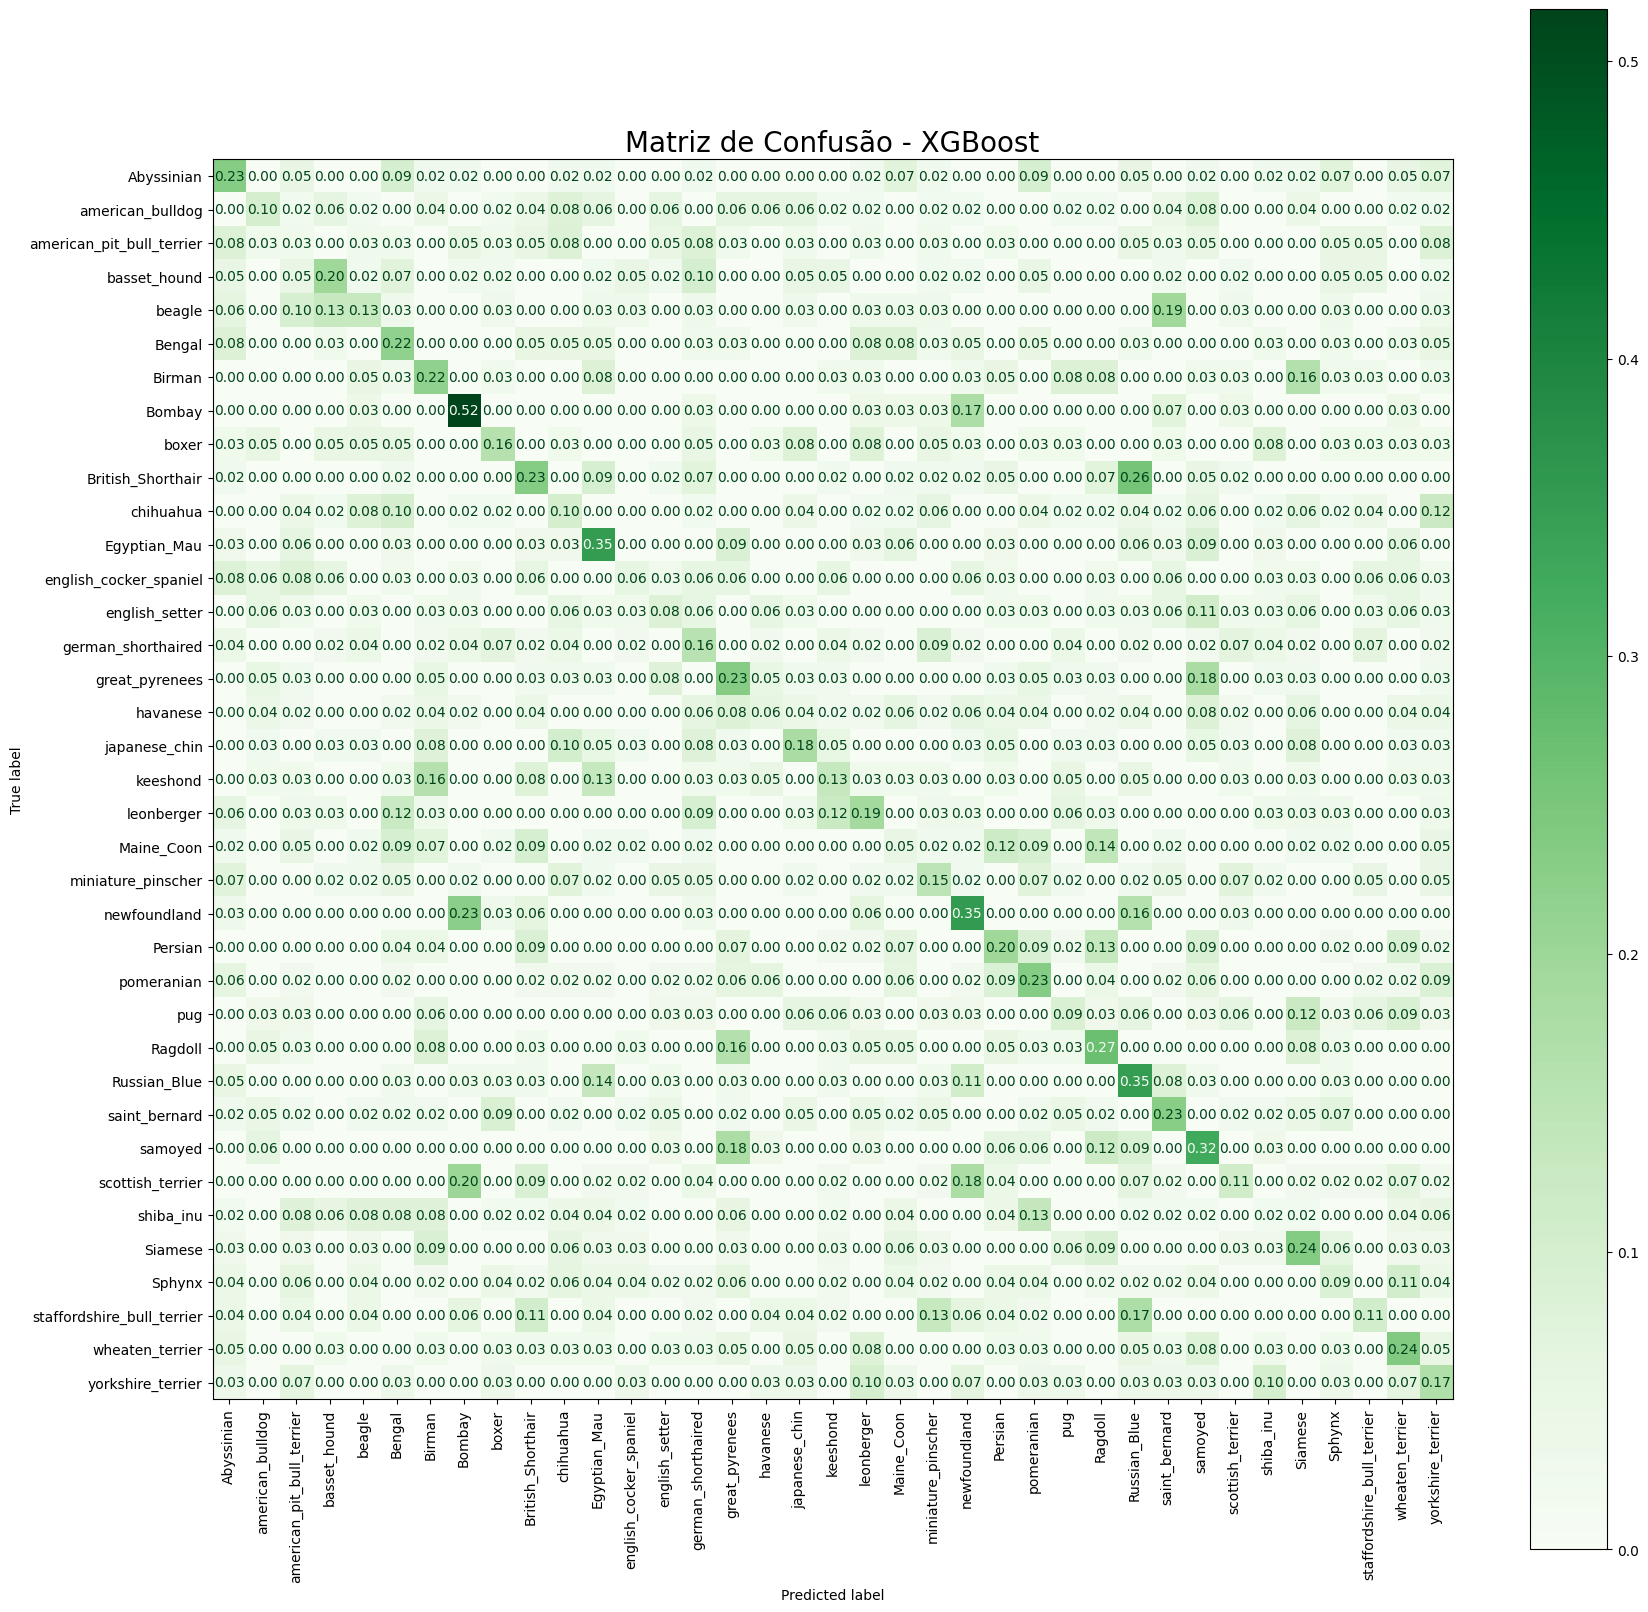

In [ ]:
# 5. Visualizar onde ele acertou mais
fig, ax = plt.subplots(figsize=(20, 20))

# Se tiver a lista de nomes, usamos ela para ficar bonito
labels_display = lista_nomes if 'lista_nomes' in locals() else le.classes_

ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_final,
    display_labels=labels_display,
    ax=ax,
    cmap='Greens', # Mudei para verde para diferenciar do RF
    normalize='true',
    xticks_rotation='vertical',
    values_format='.2f'
)

plt.title("Matriz de Confusão - XGBoost", fontsize=20)
plt.show()

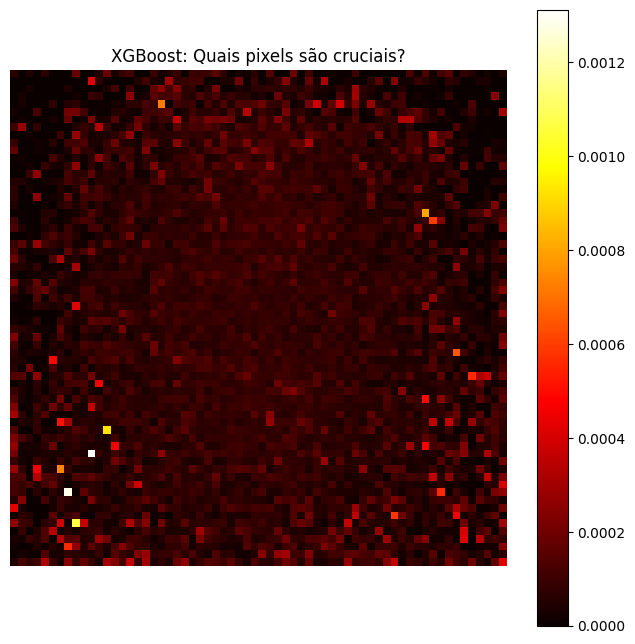

In [ ]:
# 1. Pegar as importâncias
importances_xgb = xgb_model.feature_importances_

# 2. Redimensionar para o formato da imagem (64x64x3)
# E tirar a média dos canais RGB para virar 2D
dim = 64
heatmap_xgb = importances_xgb.reshape(dim, dim, 3).mean(axis=2)

# 3. Plotar
plt.figure(figsize=(8, 8))
plt.imshow(heatmap_xgb, cmap='hot')
plt.title("XGBoost: Quais pixels são cruciais?")
plt.colorbar()
plt.axis('off')
plt.show()

# **teste visual multiclasses**

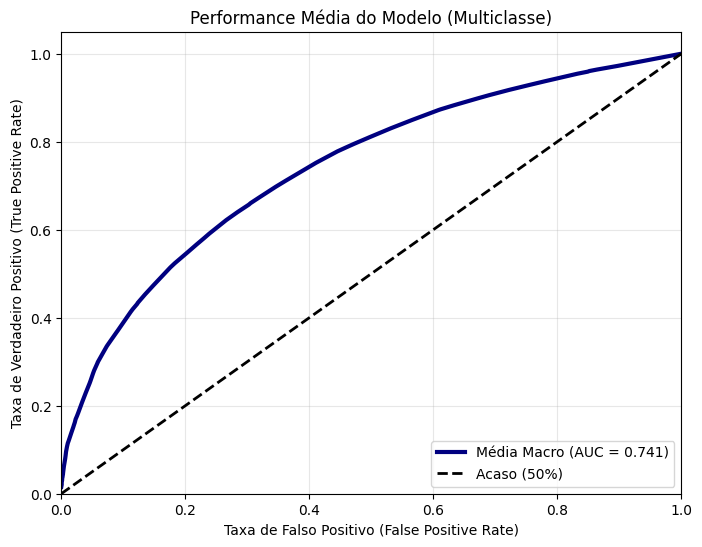

In [ ]:

# --- 1. PREPARAÇÃO (One-vs-Rest) ---
# Identifica as classes e binariza o teste
classes = np.unique(y_test_mask_mc)
n_classes = len(classes)
y_test_bin = label_binarize(y_test_mask_mc, classes=classes)

# Pega as probabilidades
y_score = rf_mask_mc.predict_proba(X_test_mask_mc)

# --- 2. CÁLCULO DA MÉDIA MACRO ---
# Primeiro, precisamos calcular a curva de CADA classe para poder fazer a média
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

# Agora agregamos todos os pontos de False Positive Rate
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolamos todas as curvas ROC nesses pontos comuns
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Tiramos a média
mean_tpr /= n_classes

# Calculamos a Área Sob a Curva (AUC) da média
macro_auc = auc(all_fpr, mean_tpr)

# --- 3. PLOTAGEM LIMPA ---
plt.figure(figsize=(8, 6))

plt.plot(
    all_fpr,
    mean_tpr,
    color='navy',
    linestyle='-',
    linewidth=3,
    label=f'Média Macro (AUC = {macro_auc:.3f})'
)

# Linha de referência (Chute Aleatório - 50%)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Acaso (50%)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiro Positivo (True Positive Rate)')
plt.title('Performance Média do Modelo (Multiclasse)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

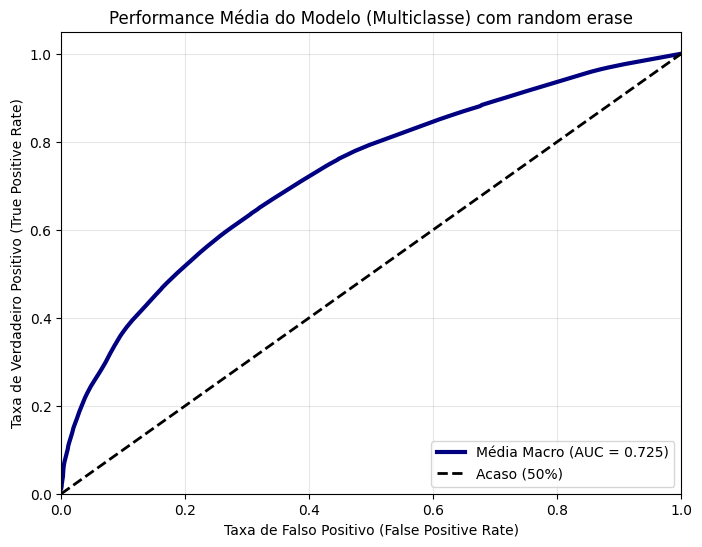

In [ ]:

# --- 1. PREPARAÇÃO (One-vs-Rest) ---
# Identifica as classes e binariza o teste
classes = np.unique(y_test_re_mc)
n_classes = len(classes)
y_test_bin = label_binarize(y_test_re_mc, classes=classes)

# Pega as probabilidades
y_score = rf_re_mc.predict_proba(X_test_re_mc)

# --- 2. CÁLCULO DA MÉDIA MACRO ---
# Primeiro, precisamos calcular a curva de CADA classe para poder fazer a média
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

# Agora agregamos todos os pontos de False Positive Rate
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolamos todas as curvas ROC nesses pontos comuns
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Tiramos a média
mean_tpr /= n_classes

# Calculamos a Área Sob a Curva (AUC) da média
macro_auc = auc(all_fpr, mean_tpr)

# --- 3. PLOTAGEM LIMPA ---
plt.figure(figsize=(8, 6))

plt.plot(
    all_fpr,
    mean_tpr,
    color='navy',
    linestyle='-',
    linewidth=3,
    label=f'Média Macro (AUC = {macro_auc:.3f})'
)

# Linha de referência (Chute Aleatório - 50%)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Acaso (50%)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiro Positivo (True Positive Rate)')
plt.title('Performance Média do Modelo (Multiclasse) com random erase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

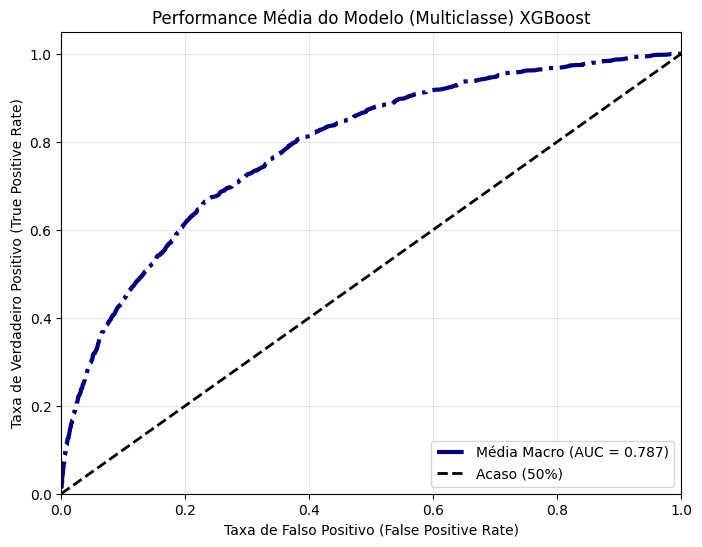

In [ ]:

# --- 1. PREPARAÇÃO (One-vs-Rest) ---
# Identifica as classes e binariza o teste
classes = np.unique(y_test_final)
n_classes = len(classes)
y_test_bin = label_binarize(y_test_final, classes=classes)

# Pega as probabilidades
y_score = xgb_model.predict_proba(X_test_final)

# --- 2. CÁLCULO DA MÉDIA MACRO ---
# Primeiro, precisamos calcular a curva de CADA classe para poder fazer a média
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

# Agora agregamos todos os pontos de False Positive Rate
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolamos todas as curvas ROC nesses pontos comuns
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Tiramos a média
mean_tpr /= n_classes

# Calculamos a Área Sob a Curva (AUC) da média
macro_auc = auc(all_fpr, mean_tpr)

# --- 3. PLOTAGEM LIMPA ---
plt.figure(figsize=(8, 6))

plt.plot(
    all_fpr,
    mean_tpr,
    color='navy',
    linestyle='-.',
    linewidth=3,
    label=f'Média Macro (AUC = {macro_auc:.3f})'
)

# Linha de referência (Chute Aleatório - 50%)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Acaso (50%)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiro Positivo (True Positive Rate)')
plt.title('Performance Média do Modelo (Multiclasse) XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()